# Setup and Data Loading

Install dependencies, load shared imports, and assemble the Raman spectra datasets.


## Cleanup Notes

- Removed the three early graphing sections.
- Removed carbon/error/peak filtering sections.
- Removed the four peak-extraction experiment sections.
- Removed LoRA-CT testing cells.
- Consolidated repeated imports and normalization logic.


In [1]:
%pip install -q pybaselines scikit-fda livelossplot


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.9/211.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.0/639.0 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.7/287.7 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [2]:
# Core utilities
import random
import time

# Data manipulation and numeric computing
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Signal processing and baseline correction
import pybaselines
import scipy.signal as signal
from scipy.signal import correlate, savgol_filter
from scipy.stats import pearsonr

# Scikit-learn utilities
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# PyTorch utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import grad
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split

# Training visualization
from livelossplot import PlotLosses

# Colab Drive data access
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# an array of file names, named by virus_subtype_strain_datetime.txt

filenames_horiba = ['/content/drive/MyDrive/Virus Stuff/FluA_H1N1_CA_17_35_10_2025_10_03_1_5 s_785 nm_600 gr_mm_x100_100_5%.txt',
                    '/content/drive/MyDrive/Virus Stuff/FluA_H3N2_NC_13_29_59_2025_10_05_1_5 s_785 nm_600 gr_mm_x100_100_5%_01.txt',
                    '/content/drive/MyDrive/Virus Stuff/FluB_FluB_FluB_08_49_05_2025_10_03_1_1 s_785 nm_600 gr_mm_x100_100_5%_01.txt',
                    '/content/drive/MyDrive/Virus Stuff/IBV_IBV_IBV_12_54_28_2025_10_02_1_5 s_785 nm_600 gr_mm_x100_100_5%_01.txt']

filenames_renishaw = ['/content/drive/MyDrive/Virus Stuff/FluA_H1N1_CA.txt', '/content/drive/MyDrive/Virus Stuff/FluA_H3N2_NC.txt', '/content/drive/MyDrive/Virus Stuff/FluB_FluB_FluB.txt', '/content/drive/MyDrive/Virus Stuff/IBV_IBV_IBV.txt']

filenames_horiba_mol = ['/content/drive/MyDrive/Virus Stuff/adenine_horiba.txt', '/content/drive/MyDrive/Virus Stuff/dl-tyr_horiba.txt', '/content/drive/MyDrive/Virus Stuff/dl-ala_horiba.txt',
                        '/content/drive/MyDrive/Virus Stuff/dl-phe_horiba.txt', '/content/drive/MyDrive/Virus Stuff/glu_horiba.txt']

filenames_renishaw_mol = ['/content/drive/MyDrive/Virus Stuff/adenine_renishaw.txt', '/content/drive/MyDrive/Virus Stuff/dl-tyr_renishaw.txt', '/content/drive/MyDrive/Virus Stuff/dl-ala_renishaw.txt',
                          '/content/drive/MyDrive/Virus Stuff/dl-phe_renishaw.txt', '/content/drive/MyDrive/Virus Stuff/glu_renishaw.txt']
filenames_renishaw_lipid_rna = '/content/drive/MyDrive/Virus Stuff/renishaw_lipid_rna.csv'
filenames_horiba_lipid_rna = '/content/drive/MyDrive/Virus Stuff/horiba_lipid_rna.csv'


In [4]:
# a simple method for reading data from a csv and skipping a certain number of columns

def read_data(filename, skipcols):
    df = pd.read_csv(filename, sep='\t', header=None)
    df = df.iloc[:, skipcols:]
    df.columns = ['wavenumber', 'intensity']
    unique_wavenumbers = sorted(df['wavenumber'].unique())
    df['index'] = df.groupby('wavenumber').cumcount()
    df = df.pivot(index='index', columns='wavenumber', values='intensity')
    df = df.reset_index(drop=True).sort_index(axis=1)
    df.columns.name = None
    return df

def read_data2(filename, skipcols):
    df = pd.read_csv(filename, sep='\t')
    df = df.iloc[:, skipcols:]
    return df


In [5]:
# creating a combined dataframe. skipping first two cols of each horiba file, as they are irrelevant

df = pd.DataFrame()
renishaw_df = pd.DataFrame()

common_wavenumbers = np.arange(450, 1451)

for file in filenames_horiba:
    small_df = read_data2(file, 2)
    virus, subtype, strain = file.split('_')[0:3]
    virus = virus.split('/')[len(virus.split('/'))-1]

    wavenumbers = small_df.columns.astype(float)
    intensities = small_df.values

    interp_df = pd.DataFrame(
        np.array([np.interp(common_wavenumbers, wavenumbers, row) for row in intensities]),
        columns=common_wavenumbers
    )

    interp_df["Virus"] = virus
    interp_df["Subtype"] = subtype
    interp_df["Strain"] = strain
    df = pd.concat([df, interp_df])

df = df.reset_index(drop=True)

for file in filenames_renishaw:
    small_df = read_data(file, 2)
    virus, subtype, strain = file.split('_')[0:3]
    strain = strain.split('.')[0]
    virus = virus.split('/')[len(virus.split('/'))-1]

    wavenumbers = small_df.columns.astype(float)
    intensities = small_df.values

    interp_df = pd.DataFrame(
        np.array([np.interp(common_wavenumbers, wavenumbers, row) for row in intensities]),
        columns=common_wavenumbers
    )

    interp_df["Virus"] = virus
    interp_df["Subtype"] = subtype
    interp_df["Strain"] = strain
    renishaw_df = pd.concat([renishaw_df, interp_df])

renishaw_df = renishaw_df.reset_index(drop=True)


In [6]:
horiba_mol_df = pd.DataFrame()
renishaw_mol_df = pd.DataFrame()

for file in filenames_horiba_mol:
    small_df = read_data2(file, 2)
    mol = file.split('_')[0]
    mol = mol.split('/')[len(mol.split('/'))-1]

    wavenumbers = small_df.columns.astype(float)
    intensities = small_df.values

    interp_df = pd.DataFrame(
        np.array([np.interp(common_wavenumbers, wavenumbers, row) for row in intensities]),
        columns=common_wavenumbers
    )

    interp_df["Virus"] = mol
    horiba_mol_df = pd.concat([horiba_mol_df, interp_df])

horiba_mol_df = horiba_mol_df.reset_index(drop=True)

for file in filenames_renishaw_mol:
    small_df = read_data(file, 2)
    mol = file.split('_')[0]
    mol = mol.split('/')[len(mol.split('/'))-1]

    wavenumbers = small_df.columns.astype(float)
    intensities = small_df.values

    interp_df = pd.DataFrame(
        np.array([np.interp(common_wavenumbers, wavenumbers, row) for row in intensities]),
        columns=common_wavenumbers
    )

    interp_df["Virus"] = mol
    renishaw_mol_df = pd.concat([renishaw_mol_df, interp_df])

    renishaw_mol_df = renishaw_mol_df.reset_index(drop=True)


In [7]:
renishaw_df['Strain'].value_counts()


,count
Strain,
CA,2025
NC,2016
FluB,2009
IBV,2009


In [8]:
horiba_mol_df


,450,451,452,453,454,455,456,457,458,459,...,1442,1443,1444,1445,1446,1447,1448,1449,1450,Virus
0,3269.163091,3244.646208,3261.211234,3291.515948,3271.192571,3312.061873,3179.808987,3211.094623,3254.005039,3274.295377,...,3379.710000,3399.767077,3477.730156,3516.481231,3551.062813,3564.680000,3525.546094,3536.077344,3561.499219,adenine
1,2901.713091,2799.539364,2863.569234,2839.414299,2843.474000,2895.031638,2810.409922,2884.132818,2883.289766,2956.007571,...,3706.750000,3709.656923,3874.327812,3837.630000,3823.022813,3808.874375,3803.154219,3827.614063,3859.128594,adenine
2,3038.323455,2938.720857,2930.563714,3003.139039,3017.678000,2965.511678,2971.714338,3051.751974,3031.058620,2994.206468,...,4592.920000,4688.320308,4841.793594,4792.249385,4756.440625,4840.057812,4675.649062,4768.133438,4584.092187,adenine
3,3342.824091,3399.355260,3373.961753,3367.546169,3301.886429,3262.434317,3362.586494,3350.696948,3373.974128,3364.828000,...,4546.440000,4624.553846,4676.606719,4703.754154,4755.687500,4711.218750,4829.603125,4793.596406,4888.977031,adenine
4,1936.010636,1945.594052,1935.613623,1975.165571,1942.208429,1933.429701,1943.643974,1977.303805,1970.672956,1946.367623,...,3170.070000,3173.290154,3276.408906,3225.523846,3207.622813,3280.982187,3343.758594,3287.727344,3276.372500,adenine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5156,3549.760156,3538.580897,3523.194468,3544.061610,3513.558336,3540.914442,3558.402091,3653.624545,3613.920208,3554.315818,...,1923.774308,1931.645000,2016.176406,1918.088750,1923.223437,1936.715000,1912.205000,1927.563385,1921.393750,glu
5157,1391.409300,1356.382198,1329.963195,1394.797714,1364.609675,1382.170494,1338.645818,1349.360000,1340.709583,1317.970182,...,1254.943538,1301.210000,1308.996719,1251.002812,1255.429063,1250.389375,1260.626563,1228.440308,1240.433906,glu
5158,1377.093619,1358.844577,1391.301065,1333.625740,1416.190520,1428.558195,1367.325727,1388.721818,1373.139688,1421.368545,...,1384.983077,1355.960000,1389.268438,1314.946406,1287.336875,1345.906562,1317.849688,1391.900615,1340.997344,glu
5159,1309.949689,1332.501990,1328.433221,1351.573091,1349.787828,1341.114844,1370.185636,1303.915455,1310.482812,1329.857818,...,1191.712923,1154.955000,1115.632812,1117.513906,1174.098438,1133.513125,1131.265938,1156.607077,1085.309219,glu


In [9]:
renishaw_lipid_rna = pd.read_csv(filenames_renishaw_lipid_rna)
horiba_lipid_rna = pd.read_csv(filenames_horiba_lipid_rna)


In [10]:
renishaw_lipid_rna['Virus'] = None
renishaw_lipid_rna['Subtype'] = None
renishaw_lipid_rna['Strain'] = None

horiba_lipid_rna['Virus'] = None
horiba_lipid_rna['Subtype'] = None
horiba_lipid_rna['Strain'] = None


In [11]:
renishaw_lipid_rna.loc[:374, 'Virus'] = 'RNA'
renishaw_lipid_rna.loc[375:, 'Virus'] = 'Lipid'

horiba_lipid_rna.loc[:374, 'Virus'] = 'RNA'
horiba_lipid_rna.loc[375:, 'Virus'] = 'Lipid'


In [12]:
renishaw_lipid_rna


,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
0,2992.090,3033.519036,3154.093459,3125.270956,3048.542119,3030.426017,3118.250047,3144.865998,3229.784447,3180.722973,...,8688.440000,8442.166437,8303.314886,7877.680909,7679.246705,7524.149659,7273.852184,RNA,None,None
1,1448.780,1441.768280,1420.732571,1422.973273,1432.165497,1400.425516,1476.764210,1424.096386,1417.812185,1466.116439,...,3019.286818,3034.881724,3131.563409,3036.118977,3143.831477,3161.371818,3129.270345,RNA,None,None
2,1278.610,1309.341796,1383.868639,1311.188184,1316.700132,1285.982895,1266.068042,1311.761003,1319.874532,1330.392197,...,2960.585909,2991.744713,3091.006705,3146.895114,3139.167727,3153.383068,3193.958736,RNA,None,None
3,2330.340,2310.392779,2235.750246,2177.204276,2191.016954,2201.329272,2112.190199,2184.870795,2098.650549,2063.937926,...,4378.881364,4448.797011,4310.635455,4315.592841,4370.014205,4341.752841,4269.932414,RNA,None,None
4,1817.470,1776.265539,1662.529017,1713.985459,1764.916093,1696.622261,1649.924059,1679.749820,1696.972148,1691.682301,...,3691.910000,3545.270920,3756.396705,3674.171477,3731.155568,3800.653182,3823.194598,RNA,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,439.597,434.308766,411.974386,390.027688,419.585848,430.619753,435.171314,413.481598,438.541503,432.934039,...,765.456864,752.497828,802.753511,752.810420,724.976625,755.472091,747.869276,Lipid,None,None
746,739.752,723.860597,675.630246,677.818819,700.712318,683.087546,669.780072,671.776466,684.433307,682.525816,...,902.260545,875.885253,861.285239,850.297523,878.642148,894.087216,857.827839,Lipid,None,None
747,378.148,371.677255,352.689138,359.621992,386.728583,351.876377,405.652157,354.471148,339.937146,344.266670,...,826.875227,881.184483,1016.020909,1012.379341,1187.135909,1191.346705,1204.822874,Lipid,None,None
748,595.583,587.942720,580.176068,634.168734,581.612258,605.416529,603.285025,636.145279,575.090180,594.698733,...,642.751591,627.767414,661.760841,653.613625,690.100227,640.116864,673.402529,Lipid,None,None


# filter by peaks

In [13]:
def get_spectral_columns(frame, metadata_cols=("Virus", "Subtype", "Strain")):
    """Return columns whose labels and values are numeric Raman coordinates."""
    spectral_cols = []
    for col in frame.columns:
        if col in metadata_cols:
            continue
        try:
            float(col)
        except (TypeError, ValueError):
            continue
        if pd.api.types.is_numeric_dtype(frame[col]):
            spectral_cols.append(col)
    return sorted(spectral_cols, key=float)


def filter_by_peaks(frame, prominence, distance, percentile):
    """Keep spectra at or above the requested peak-count percentile."""
    spectral_cols = get_spectral_columns(frame)
    if not spectral_cols:
        raise ValueError("No numeric spectral columns were found.")

    spectra = frame[spectral_cols].to_numpy(dtype=float)
    if spectra.shape[1] < 11:
        raise ValueError("At least 11 spectral points are required for smoothing.")

    peak_counts = []
    for spectrum in spectra:
        smoothed = savgol_filter(spectrum, window_length=11, polyorder=3)
        peaks, _ = signal.find_peaks(
            smoothed,
            prominence=prominence,
            distance=distance,
        )
        peak_counts.append(len(peaks))

    peak_counts = np.asarray(peak_counts)
    threshold = np.percentile(peak_counts, percentile)
    keep_mask = peak_counts >= threshold
    clean_frame = frame.loc[keep_mask].copy().reset_index(drop=True)

    print("Original rows:", len(frame))
    print("Kept rows:", len(clean_frame))
    print("Removed rows:", int((~keep_mask).sum()))
    print("Peak-count threshold:", threshold)
    return clean_frame

In [14]:
df

,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
0,23588.0,23518.744877,23264.054286,23001.594286,22633.157588,22535.524545,22380.626234,22422.752796,22324.054805,22081.953576,...,18116.915625,18158.331250,18347.710937,18323.318750,18554.800000,18451.218750,18659.676923,FluA,H1N1,CA
1,9040.0,9053.256680,9030.924519,9015.378571,9025.338379,9057.465065,8973.977494,9084.744954,9199.510740,9236.460936,...,9466.070937,9398.546875,9336.133438,9355.149063,9180.470000,9158.501250,9080.864615,FluA,H1N1,CA
2,5031.0,5018.056744,4943.595558,4942.231429,4877.153294,4865.006039,4808.234610,4755.316697,4737.923831,4666.102497,...,3782.999375,3742.365937,3717.891562,3668.725781,3702.185000,3724.898125,3680.556923,FluA,H1N1,CA
3,2601.0,2599.855422,2623.665636,2620.865143,2621.028742,2651.056870,2641.391377,2609.527737,2643.741506,2609.757412,...,2504.282188,2496.297812,2545.327969,2528.593594,2523.405000,2544.576875,2552.315385,FluA,H1N1,CA
4,6575.0,6578.022802,6550.409818,6595.770857,6602.055681,6581.084208,6610.590701,6555.130910,6500.440052,6532.717659,...,4774.114375,4826.520625,4815.567187,4841.895313,4797.260000,4810.728750,4916.206923,FluA,H1N1,CA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8178,5481.0,5468.515519,5432.074156,5448.001556,5462.472909,5450.272481,5508.284169,5412.546117,5470.425338,5511.177286,...,5406.531094,5414.499538,5397.339375,5348.887077,5337.407656,5337.988125,5271.848000,IBV,IBV,IBV
8179,5530.0,5538.250195,5565.867273,5574.802776,5574.846455,5635.183247,5644.955156,5704.559052,5716.488312,5779.149571,...,5088.258906,5067.415231,5081.920625,5113.424154,5036.494219,5060.207344,5101.816769,IBV,IBV,IBV
8180,4615.0,4616.499026,4677.940584,4672.362322,4755.576818,4668.965130,4697.896299,4776.158636,4817.017078,4816.666429,...,4209.586406,4233.259231,4326.585625,4301.706923,4262.178594,4271.334844,4323.132154,IBV,IBV,IBV
8181,2674.0,2689.464026,2704.938247,2672.301647,2676.601909,2682.294987,2648.485896,2670.790701,2678.447844,2677.720571,...,2257.825312,2193.935846,2175.594375,2259.062154,2186.890156,2179.911406,2167.195077,IBV,IBV,IBV


In [15]:
clean_df = filter_by_peaks(df, prominence=30, distance=25, percentile=25)

Original rows: 8183
Kept rows: 6641
Removed rows: 1542
Peak-count threshold: 19.0


# ASLS

In [16]:
# ASLS (Asymmetric Least-Squares)

def subtract_baseline(row):
  baseline, _ = pybaselines.whittaker.asls(row.to_numpy(dtype=float), lam=1e5, p=0.01)
  return row - baseline


In [17]:
metadata = df.iloc[:, -3:]

subbed_df = df.iloc[:, :-3].apply(subtract_baseline, axis=1)
subbed_df = pd.concat([subbed_df, metadata], axis=1)

subbed_renishaw = renishaw_df.iloc[:, :-3].apply(subtract_baseline, axis=1)
subbed_renishaw = pd.concat([subbed_renishaw, renishaw_df.iloc[:, -3:]], axis=1)


In [18]:
subbed_horiba_mol = horiba_mol_df.iloc[:, :-1].apply(subtract_baseline, axis=1)
subbed_horiba_mol = pd.concat([subbed_horiba_mol, horiba_mol_df.iloc[:, -1:]], axis=1)

subbed_renishaw_mol = renishaw_mol_df.iloc[:, :-1].apply(subtract_baseline, axis=1)
subbed_renishaw_mol = pd.concat([subbed_renishaw_mol, renishaw_mol_df.iloc[:, -1:]], axis=1)


In [19]:
subbed_renishaw['Strain'].value_counts()


,count
Strain,
CA,2025
NC,2016
FluB,2009
IBV,2009


In [20]:
subbed_renishaw_lipid_rna = renishaw_lipid_rna.iloc[:, :-3].apply(subtract_baseline, axis=1)
subbed_renishaw_lipid_rna = pd.concat([subbed_renishaw_lipid_rna, renishaw_lipid_rna.iloc[:, -3:]], axis=1)

subbed_horiba_lipid_rna = horiba_lipid_rna.iloc[:, :-3].apply(subtract_baseline, axis=1)
subbed_horiba_lipid_rna = pd.concat([subbed_horiba_lipid_rna, horiba_lipid_rna.iloc[:, -3:]], axis=1)


# Normalize Spectra

Apply per-spectrum min-max normalization while preserving metadata columns.


In [21]:
def normalize_spectra(df, n_metadata_cols):
    """Min-max normalize spectral columns row-wise and append metadata unchanged."""
    spectra = df.iloc[:, :-n_metadata_cols]
    metadata = df.iloc[:, -n_metadata_cols:].reset_index(drop=True)

    normalized = pd.DataFrame(
        MinMaxScaler().fit_transform(spectra.T).T,
        columns=spectra.columns,
    )
    return pd.concat([normalized, metadata], axis=1)


norm_df = normalize_spectra(subbed_df, 3)
norm_renishaw = normalize_spectra(subbed_renishaw, 3)
norm_horiba_mol = normalize_spectra(subbed_horiba_mol, 1)
norm_renishaw_mol = normalize_spectra(subbed_renishaw_mol, 1)
norm_horiba_lipid_rna = normalize_spectra(subbed_horiba_lipid_rna, 3)
norm_renishaw_lipid_rna = normalize_spectra(subbed_renishaw_lipid_rna, 3)


In [22]:
norm_horiba_lipid_rna


,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
0,0.248819,0.269177,0.270794,0.237329,0.200767,0.215820,0.209113,0.312500,0.244604,0.212257,...,0.198296,0.200207,0.254613,0.250346,0.228688,0.231896,0.225072,RNA,None,None
1,0.231653,0.228873,0.205902,0.206010,0.149747,0.180177,0.193333,0.238147,0.187807,0.195044,...,0.264832,0.255106,0.275593,0.263499,0.281536,0.301358,0.283686,RNA,None,None
2,0.112820,0.104345,0.087658,0.114895,0.122667,0.100055,0.125308,0.102390,0.173557,0.131540,...,0.269994,0.201891,0.208716,0.293844,0.289513,0.277688,0.231356,RNA,None,None
3,0.303739,0.305881,0.302368,0.290297,0.250164,0.256508,0.272725,0.241492,0.248251,0.239771,...,0.196267,0.255645,0.283107,0.312998,0.415578,0.458025,0.511478,RNA,None,None
4,0.076028,0.082335,0.094844,0.096342,0.099160,0.137654,0.138650,0.135749,0.154633,0.157671,...,0.330668,0.318063,0.349380,0.354153,0.377435,0.405040,0.394881,RNA,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.120955,0.115952,0.098673,0.141202,0.086399,0.086519,0.071147,0.066950,0.114683,0.098462,...,0.067367,0.026381,0.107602,0.092750,0.076739,0.036059,0.045033,Lipid,None,None
746,0.243701,0.254938,0.323203,0.379185,0.390608,0.330583,0.292423,0.203009,0.139460,0.143947,...,0.103231,0.141652,0.184793,0.228288,0.279691,0.243290,0.334831,Lipid,None,None
747,0.233404,0.271014,0.361179,0.317449,0.301888,0.274750,0.244785,0.263440,0.181727,0.277039,...,0.334921,0.385662,0.407692,0.445361,0.407623,0.342432,0.460008,Lipid,None,None
748,0.209253,0.211445,0.271954,0.380374,0.178492,0.250696,0.201641,0.176182,0.322835,0.416785,...,0.416067,0.538873,0.376695,0.298917,0.310683,0.360861,0.325298,Lipid,None,None


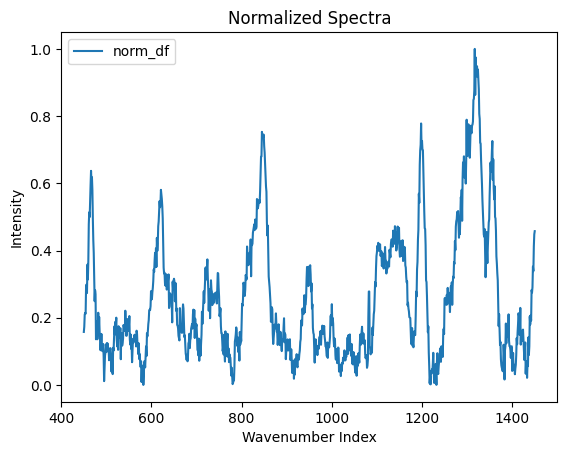

In [23]:
sample_idx = random.choice(norm_df.index.tolist())
spectral_cols = [c for c in norm_df.columns if isinstance(c, (int, float))]
y_norm = norm_df.loc[sample_idx, spectral_cols].values
plt.figure()
plt.plot(spectral_cols, y_norm, label="norm_df")
plt.xlabel("Wavenumber Index")
plt.ylabel("Intensity")
plt.title("Normalized Spectra")
plt.legend()
plt.show()


# Data Sampling

Build balanced Horiba/Renishaw datasets for transfer learning and classification.


In [24]:
renishaw_flua = norm_renishaw.query("Strain == 'CA'")

horiba_flua = norm_df.query("Strain == 'CA'")

# 1) Strains present in BOTH dataframes
common_strains = np.intersect1d(
    renishaw_flua['Strain'].dropna().astype(str).unique(),
    horiba_flua['Strain'].dropna().astype(str).unique()
)

renishaw_common = renishaw_flua[renishaw_flua['Strain'].astype(str).isin(common_strains)]
horiba_common   = horiba_flua[horiba_flua['Strain'].astype(str).isin(common_strains)]

# 2) If you want EXACTLY n per strain on both sides, keep only strains with >= n rows in BOTH dfs
n = 750
need = 2 * n
ok = (
    renishaw_common['Strain'].value_counts().to_frame('m')
    .join(horiba_common['Strain'].value_counts().to_frame('s'), how='inner')
)
eligible_strains = ok.index[(ok[['m','s']].min(axis=1) >= n)]

renishaw_ok = renishaw_common[renishaw_common['Strain'].isin(eligible_strains)]
horiba_ok   = horiba_common[horiba_common['Strain'].isin(eligible_strains)]

# 3) Sample n per strain (no replacement). Set replace=True if some groups are smaller than n.
renishaw_flua_sample = (renishaw_ok
    .groupby('Strain', group_keys=False)
    .sample(n=n, replace=False, random_state=42)
    .reset_index(drop=True))

horiba_flua_sample = (horiba_ok
    .groupby('Strain', group_keys=False)
    .sample(n=n, replace=False, random_state=42)
    .reset_index(drop=True))

# (Optional) If you still want to split into "metadata" and "spectra" like your code:
renishaw_flua_metadata = renishaw_flua_sample.iloc[:, -3:]   # adjust if your meta cols differ
renishaw_flua_spectra  = renishaw_flua_sample.iloc[:, :-3]

horiba_flua_metadata   = horiba_flua_sample.iloc[:, -3:]
horiba_flua_spectra    = horiba_flua_sample.iloc[:, :-3]


In [25]:

# Select FluA CA and NC from both instruments
target_strains = ["CA", "NC"]
n = 750

renishaw_flua = norm_renishaw.query("Virus == 'FluA' and Strain in @target_strains").copy()
horiba_flua = norm_df.query("Virus == 'FluA' and Strain in @target_strains").copy()

# Keep only strains that exist in both datasets
common_strains = np.intersect1d(
    renishaw_flua["Strain"].dropna().astype(str).unique(),
    horiba_flua["Strain"].dropna().astype(str).unique(),
)

common_strains = [s for s in common_strains if s in target_strains]

renishaw_common = renishaw_flua[renishaw_flua["Strain"].astype(str).isin(common_strains)].copy()
horiba_common = horiba_flua[horiba_flua["Strain"].astype(str).isin(common_strains)].copy()

# Require at least n samples for each strain in both instruments
counts = (
    renishaw_common["Strain"].value_counts().to_frame("renishaw")
    .join(horiba_common["Strain"].value_counts().to_frame("horiba"), how="inner")
)

eligible_strains = counts.index[counts[["renishaw", "horiba"]].min(axis=1) >= n]

print(counts)
print("Eligible strains:", list(eligible_strains))

# Sample n per strain
renishaw_flua_sample = (
    renishaw_common[renishaw_common["Strain"].isin(eligible_strains)]
    .groupby("Strain", group_keys=False)
    .sample(n=n, replace=False, random_state=42)
    .reset_index(drop=True)
)

horiba_flua_sample = (
    horiba_common[horiba_common["Strain"].isin(eligible_strains)]
    .groupby("Strain", group_keys=False)
    .sample(n=n, replace=False, random_state=42)
    .reset_index(drop=True)
)

# Optional: preserve original virus label before overwriting it
#renishaw_flua_sample["OriginalVirus"] = renishaw_flua_sample["Virus"]
#horiba_flua_sample["OriginalVirus"] = horiba_flua_sample["Virus"]

# Relabel Virus as strain class: "CA" or "NC"
renishaw_flua_sample["Virus"] = renishaw_flua_sample["Strain"].astype(str)
horiba_flua_sample["Virus"] = horiba_flua_sample["Strain"].astype(str)

print("Renishaw labels:")
print(renishaw_flua_sample["Virus"].value_counts())

print("Horiba labels:")
print(horiba_flua_sample["Virus"].value_counts())


        renishaw  horiba
Strain                  
CA          2025    2052
NC          2016    2040
Eligible strains: ['CA', 'NC']
Renishaw labels:
Virus
CA    750
NC    750
Name: count, dtype: int64
Horiba labels:
Virus
CA    750
NC    750
Name: count, dtype: int64


In [26]:
renishaw_2n = (renishaw_ok
    .groupby('Strain', group_keys=False)
    .sample(n=need, replace=False, random_state=42)
    .reset_index(drop=True))

horiba_2n = (horiba_ok
    .groupby('Strain', group_keys=False)
    .sample(n=need, replace=False, random_state=42)
    .reset_index(drop=True))

renishaw_set1 = renishaw_2n.groupby('Strain', group_keys=False).head(n).reset_index(drop=True)
renishaw_set2 = renishaw_2n.groupby('Strain', group_keys=False).tail(n).reset_index(drop=True)

horiba_set1   = horiba_2n.groupby('Strain', group_keys=False).head(n).reset_index(drop=True)
horiba_set2   = horiba_2n.groupby('Strain', group_keys=False).tail(n).reset_index(drop=True)

# (Optional) metadata/spectra splits for each set
renishaw_set1_metadata = renishaw_set1.iloc[:, -3:]
renishaw_set1_spectra  = renishaw_set1.iloc[:, :-3]
renishaw_set2_metadata = renishaw_set2.iloc[:, -3:]
renishaw_set2_spectra  = renishaw_set2.iloc[:, :-3]

horiba_set1_metadata   = horiba_set1.iloc[:, -3:]
horiba_set1_spectra    = horiba_set1.iloc[:, :-3]
horiba_set2_metadata   = horiba_set2.iloc[:, -3:]
horiba_set2_spectra    = horiba_set2.iloc[:, :-3]

# (Optional sanity checks)
# no overlap within each dataset (by full row identity)
assert len(pd.merge(renishaw_set1, renishaw_set2, how="inner")) == 0
assert len(pd.merge(horiba_set1, horiba_set2, how="inner")) == 0


In [27]:
renishaw_set1['Virus'].value_counts()


,count
Virus,
FluA,750


In [28]:
renishaw_flua = pd.concat([renishaw_flua_spectra, renishaw_flua_metadata], axis=1)
horiba_flua = pd.concat([horiba_flua_spectra, horiba_flua_metadata], axis=1)


In [29]:
horiba_flua['Strain'].value_counts()


,count
Strain,
CA,750


In [30]:
sampled_renishaw = norm_renishaw.copy()
sampled_horiba = norm_df.copy()


def sample_up_to_n(group, n, random_state=42):
    """Sample without replacement, capped at the available group size."""
    return group.sample(n=min(n, len(group)), random_state=random_state)


sampled_renishaw = (
    sampled_renishaw.groupby("Strain", group_keys=False)
    .apply(sample_up_to_n, n=750)
    .reset_index(drop=True)
)
sampled_horiba = (
    sampled_horiba.groupby("Strain", group_keys=False)
    .apply(sample_up_to_n, n=750)
    .reset_index(drop=True)
)
renishaw_metadata = sampled_renishaw.iloc[:, -3:]
horiba_metadata = sampled_horiba.iloc[:, -3:]

/tmp/ipykernel_827/2585331618.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=750)
/tmp/ipykernel_827/2585331618.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=750)


In [31]:
horiba_mol_sample = (norm_horiba_mol
                     .groupby('Virus')
                     .apply(sample_up_to_n, n=750)
                     .reset_index(drop=True))
renishaw_mol_sample = (norm_renishaw_mol
                     .groupby('Virus')
                     .apply(sample_up_to_n, n=750)
                     .reset_index(drop=True))

/tmp/ipykernel_827/4103765356.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=750)
/tmp/ipykernel_827/4103765356.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=750)


In [32]:
sampled_horiba = sampled_horiba.query("Virus != 'FluA'")
sampled_renishaw = sampled_renishaw.query("Virus != 'FluA'")

#sampled_horiba = sampled_horiba.query("Virus != 'FluB'")
#sampled_renishaw = sampled_renishaw.query("Virus != 'FluB'")

#sampled_horiba = sampled_horiba.query("Virus != 'IBV'")
#sampled_renishaw = sampled_renishaw.query("Virus != 'IBV'")

#sampled_horiba = sampled_horiba.query("Strain != 'NC'")
#sampled_renishaw = sampled_renishaw.query("Strain != 'NC'")


In [33]:
sampled_horiba


,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
750,0.041479,0.042076,0.042558,0.041369,0.038320,0.030933,0.030200,0.023076,0.022399,0.015052,...,0.078445,0.074475,0.075229,0.068796,0.063361,0.062373,0.062529,FluB,FluB,FluB
751,0.123266,0.146509,0.187083,0.203401,0.221914,0.280404,0.304994,0.338735,0.373261,0.412607,...,0.289835,0.294396,0.316424,0.283590,0.294348,0.311564,0.338998,FluB,FluB,FluB
752,0.506833,0.538591,0.588236,0.574940,0.628012,0.629970,0.630135,0.573755,0.560713,0.517206,...,0.498091,0.490281,0.632461,0.635337,0.719200,0.730586,0.807603,FluB,FluB,FluB
753,0.415294,0.375988,0.152809,0.181590,0.185540,0.210165,0.210502,0.265353,0.158243,0.253792,...,0.519284,0.627161,0.480823,0.614869,0.660399,0.697023,0.710494,FluB,FluB,FluB
754,0.245064,0.267078,0.180891,0.297915,0.447934,0.443614,0.303290,0.508245,0.542787,0.452344,...,0.447707,0.576376,0.444630,0.564869,0.463834,0.527962,0.433957,FluB,FluB,FluB
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2245,0.153381,0.144967,0.158078,0.101742,0.156856,0.160959,0.140436,0.143500,0.147880,0.135641,...,0.418210,0.355329,0.358415,0.343136,0.313367,0.324935,0.315101,IBV,IBV,IBV
2246,0.442658,0.445355,0.395343,0.316630,0.360538,0.308364,0.241763,0.289106,0.246302,0.239253,...,0.318380,0.282256,0.221634,0.190955,0.227744,0.202561,0.202904,IBV,IBV,IBV
2247,0.166160,0.159418,0.178087,0.130319,0.275483,0.404760,0.464950,0.448450,0.380311,0.323694,...,0.467041,0.498226,0.667280,0.571736,0.586051,0.502724,0.517294,IBV,IBV,IBV
2248,0.086621,0.090769,0.070512,0.094403,0.079779,0.090909,0.091917,0.074122,0.091805,0.061651,...,0.079132,0.068763,0.081718,0.059901,0.049335,0.074498,0.076140,IBV,IBV,IBV


In [34]:
horiba_mol_sample['Subtype'] = 'None'
horiba_mol_sample['Strain'] = 'None'

renishaw_mol_sample['Subtype'] = 'None'
renishaw_mol_sample['Strain'] = 'None'


In [35]:
horiba_mol_sample['Virus'].value_counts()


,count
Virus,
adenine,750
dl-ala,750
dl-phe,750
dl-tyr,750
glu,750


In [36]:
#horiba_mol_sample = horiba_mol_sample.query("Virus == 'adenine'")
#renishaw_mol_sample = renishaw_mol_sample.query("Virus == 'adenine'")


In [37]:
norm_renishaw_lipid_rna


,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
0,0.044929,0.055443,0.084414,0.078547,0.061509,0.058140,0.079474,0.086535,0.107192,0.096608,...,0.393359,0.332643,0.296976,0.194435,0.144875,0.105420,0.043766,RNA,None,None
1,0.158619,0.152478,0.130374,0.134764,0.147066,0.112778,0.201509,0.143400,0.138086,0.194907,...,0.322974,0.344468,0.458256,0.353360,0.479704,0.503410,0.470613,RNA,None,None
2,0.144001,0.181483,0.270880,0.185778,0.193364,0.158005,0.135451,0.190668,0.201338,0.214857,...,0.709439,0.748697,0.868682,0.937252,0.930412,0.949582,1.000000,RNA,None,None
3,0.496867,0.474146,0.382091,0.310441,0.330516,0.346153,0.235721,0.330418,0.223685,0.182244,...,0.721800,0.817987,0.650405,0.664246,0.740790,0.712522,0.629036,RNA,None,None
4,0.317509,0.259977,0.099848,0.173385,0.246179,0.150328,0.085025,0.127965,0.153077,0.146346,...,0.787955,0.584926,0.887955,0.776038,0.861032,0.963726,1.000000,RNA,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,0.307839,0.286692,0.197759,0.110368,0.227793,0.271553,0.289537,0.203168,0.302708,0.280295,...,0.299022,0.249661,0.451682,0.255248,0.146735,0.270176,0.242114,Lipid,None,None
746,0.344245,0.311514,0.210433,0.215916,0.265160,0.228766,0.201496,0.206572,0.234179,0.231002,...,0.244855,0.194452,0.168938,0.151058,0.216310,0.254297,0.183004,Lipid,None,None
747,0.146375,0.136782,0.108396,0.118928,0.159749,0.107544,0.188406,0.111685,0.089985,0.096608,...,0.431621,0.513318,0.715918,0.710604,0.973139,0.979614,1.000000,Lipid,None,None
748,0.296574,0.264761,0.232424,0.456159,0.238111,0.336675,0.327703,0.463816,0.210529,0.291695,...,0.266822,0.212110,0.360472,0.334106,0.492805,0.292975,0.438402,Lipid,None,None


In [38]:
def fix_mixed_columns(df):
    new_cols = []

    for col in df.columns:
        try:
            # convert wavelength-like columns: "450" -> 450
            new_cols.append(int(float(col)))
        except (TypeError, ValueError):
            # keep non-numeric columns like "label", "type", etc.
            new_cols.append(col)

    df = df.copy()
    df.columns = new_cols
    return df


norm_horiba_lipid_rna = fix_mixed_columns(norm_horiba_lipid_rna)

norm_renishaw_lipid_rna = fix_mixed_columns(norm_renishaw_lipid_rna)

In [39]:
# Combine the molecular and lipid/RNA experiments. Virus spectra can be added
# here later if they are part of the classification question.
horiba_everything = pd.concat(
    [horiba_mol_sample, norm_horiba_lipid_rna],
    axis=0,
    ignore_index=True,
)
renishaw_everything = pd.concat(
    [renishaw_mol_sample, norm_renishaw_lipid_rna],
    axis=0,
    ignore_index=True,
)

In [40]:
#horiba_everything = pd.concat([horiba_everything, horiba_flua_sample], axis=0)
#renishaw_everything = pd.concat([renishaw_everything, renishaw_flua_sample], axis=0)

In [41]:
horiba_everything['Virus'].value_counts()


,count
Virus,
adenine,750
dl-ala,750
dl-phe,750
dl-tyr,750
glu,750
RNA,375
Lipid,375


In [42]:
horiba_everything


,450,451,452,453,454,455,456,457,458,459,...,1444,1445,1446,1447,1448,1449,1450,Virus,Subtype,Strain
0,0.043083,0.041606,0.045071,0.041589,0.047674,0.048541,0.041094,0.036792,0.029718,0.035937,...,0.171130,0.182903,0.181293,0.184411,0.181146,0.180628,0.185910,adenine,None,None
1,0.034018,0.029939,0.038426,0.037149,0.036553,0.034334,0.030238,0.037424,0.034567,0.023828,...,0.147652,0.151953,0.159118,0.163804,0.167845,0.168515,0.168273,adenine,None,None
2,0.037365,0.037414,0.035671,0.036161,0.029404,0.029358,0.039614,0.032079,0.029076,0.030315,...,0.169435,0.180521,0.189639,0.201446,0.202423,0.217448,0.213532,adenine,None,None
3,0.041881,0.040419,0.038913,0.042708,0.040538,0.037994,0.040990,0.039308,0.037925,0.033701,...,0.174904,0.177062,0.190580,0.186673,0.192236,0.192947,0.197473,adenine,None,None
4,0.042533,0.033678,0.031971,0.042148,0.038365,0.039792,0.028405,0.031023,0.039149,0.037384,...,0.171600,0.174275,0.178609,0.190710,0.193759,0.196309,0.200202,adenine,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,0.120955,0.115952,0.098673,0.141202,0.086399,0.086519,0.071147,0.066950,0.114683,0.098462,...,0.067367,0.026381,0.107602,0.092750,0.076739,0.036059,0.045033,Lipid,None,None
4496,0.243701,0.254938,0.323203,0.379185,0.390608,0.330583,0.292423,0.203009,0.139460,0.143947,...,0.103231,0.141652,0.184793,0.228288,0.279691,0.243290,0.334831,Lipid,None,None
4497,0.233404,0.271014,0.361179,0.317449,0.301888,0.274750,0.244785,0.263440,0.181727,0.277039,...,0.334921,0.385662,0.407692,0.445361,0.407623,0.342432,0.460008,Lipid,None,None
4498,0.209253,0.211445,0.271954,0.380374,0.178492,0.250696,0.201641,0.176182,0.322835,0.416785,...,0.416067,0.538873,0.376695,0.298917,0.310683,0.360861,0.325298,Lipid,None,None


# cut carbon peak from amino acids

In [43]:
def cut_carbon_peak(df, low=1250, high=1450):
    # columns are wavenumbers like 450, 451, ..., 1449
    wavenumbers = pd.to_numeric(df.columns, errors="coerce")
    keep = (wavenumbers.isna()) | (wavenumbers < low) | (wavenumbers > high)
    return df.loc[:, keep]

horiba_everything_cut = cut_carbon_peak(horiba_everything)
renishaw_everything_cut = cut_carbon_peak(renishaw_everything)

print(horiba_everything.shape, "->", horiba_everything_cut.shape)
print(renishaw_everything.shape, "->", renishaw_everything_cut.shape)

(4500, 1004) -> (4500, 803)
(4500, 1004) -> (4500, 803)


In [44]:
horiba_everything = horiba_everything_cut
renishaw_everything = renishaw_everything_cut

In [45]:
renishaw_everything

,450,451,452,453,454,455,456,457,458,459,...,1243,1244,1245,1246,1247,1248,1249,Virus,Subtype,Strain
0,0.037037,0.033889,0.033259,0.033420,0.028151,0.027771,0.030555,0.029843,0.032869,0.028371,...,0.062494,0.052316,0.051648,0.052904,0.052928,0.048140,0.042554,adenine,None,None
1,0.049334,0.047919,0.053007,0.052972,0.049121,0.054421,0.048076,0.045423,0.056070,0.054236,...,0.021843,0.020545,0.021322,0.016199,0.032319,0.025638,0.027364,adenine,None,None
2,0.034093,0.029923,0.027370,0.030232,0.033651,0.035882,0.032241,0.033834,0.035245,0.027135,...,0.034752,0.041385,0.034991,0.040502,0.046129,0.048390,0.048164,adenine,None,None
3,0.044924,0.040966,0.039694,0.042264,0.042165,0.043902,0.044021,0.040289,0.041319,0.037015,...,0.029306,0.025995,0.028252,0.024686,0.021963,0.021203,0.023990,adenine,None,None
4,0.051150,0.053881,0.056142,0.058664,0.056871,0.057284,0.049619,0.044806,0.056475,0.042766,...,0.046364,0.033409,0.044490,0.063740,0.051589,0.053807,0.046164,adenine,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,0.307839,0.286692,0.197759,0.110368,0.227793,0.271553,0.289537,0.203168,0.302708,0.280295,...,0.369122,0.364280,0.321334,0.371443,0.521495,0.347869,0.442843,Lipid,None,None
4496,0.344245,0.311514,0.210433,0.215916,0.265160,0.228766,0.201496,0.206572,0.234179,0.231002,...,0.385801,0.366055,0.337898,0.319810,0.319732,0.430045,0.365264,Lipid,None,None
4497,0.146375,0.136782,0.108396,0.118928,0.159749,0.107544,0.188406,0.111685,0.089985,0.096608,...,0.094470,0.130736,0.080434,0.124308,0.138619,0.095300,0.049333,Lipid,None,None
4498,0.296574,0.264761,0.232424,0.456159,0.238111,0.336675,0.327703,0.463816,0.210529,0.291695,...,0.469442,0.348328,0.317201,0.360281,0.211404,0.201480,0.203158,Lipid,None,None


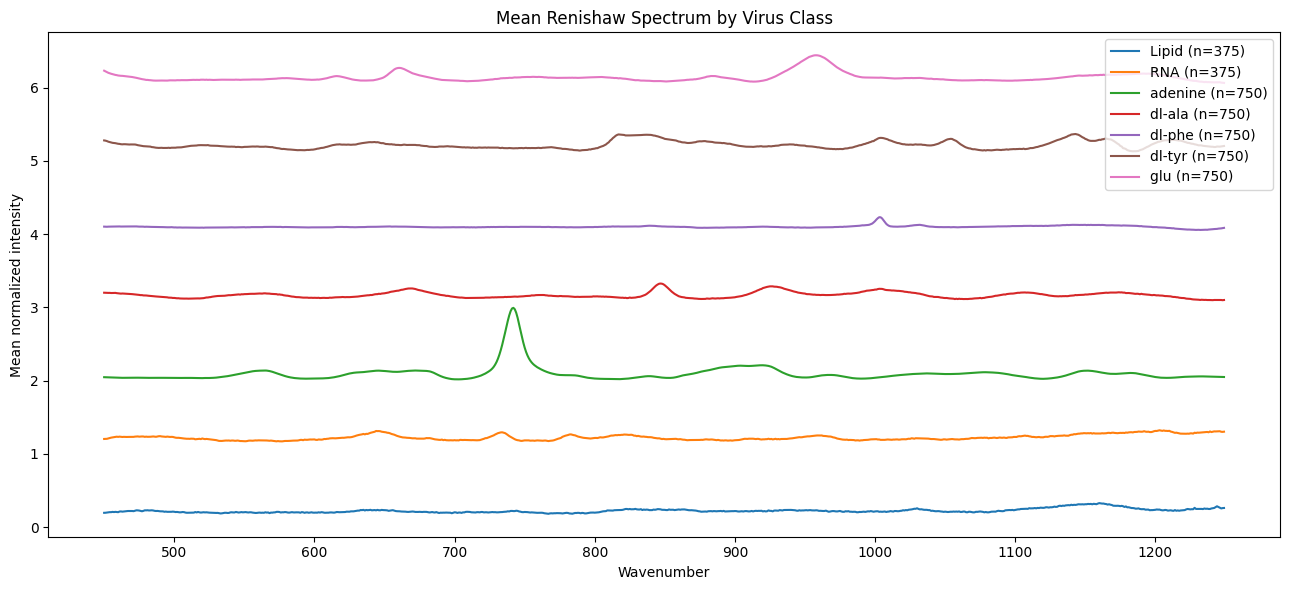

In [46]:
df_plot = renishaw_everything.copy()

label_col = "Virus"
metadata_cols = ["Virus", "Subtype", "Strain"]

spectral_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

wavenumbers = np.array(spectral_cols, dtype=float)

class_means = (
    df_plot
    .groupby(label_col)[spectral_cols]
    .mean()
)

plt.figure(figsize=(13, 6))

for i, (virus, row) in enumerate(class_means.iterrows()):
    plt.plot(wavenumbers, row.values+i, label=f"{virus} (n={(df_plot[label_col] == virus).sum()})")

plt.xlabel("Wavenumber")
plt.ylabel("Mean normalized intensity")
plt.title("Mean Renishaw Spectrum by Virus Class")
plt.legend()
plt.tight_layout()
plt.show()

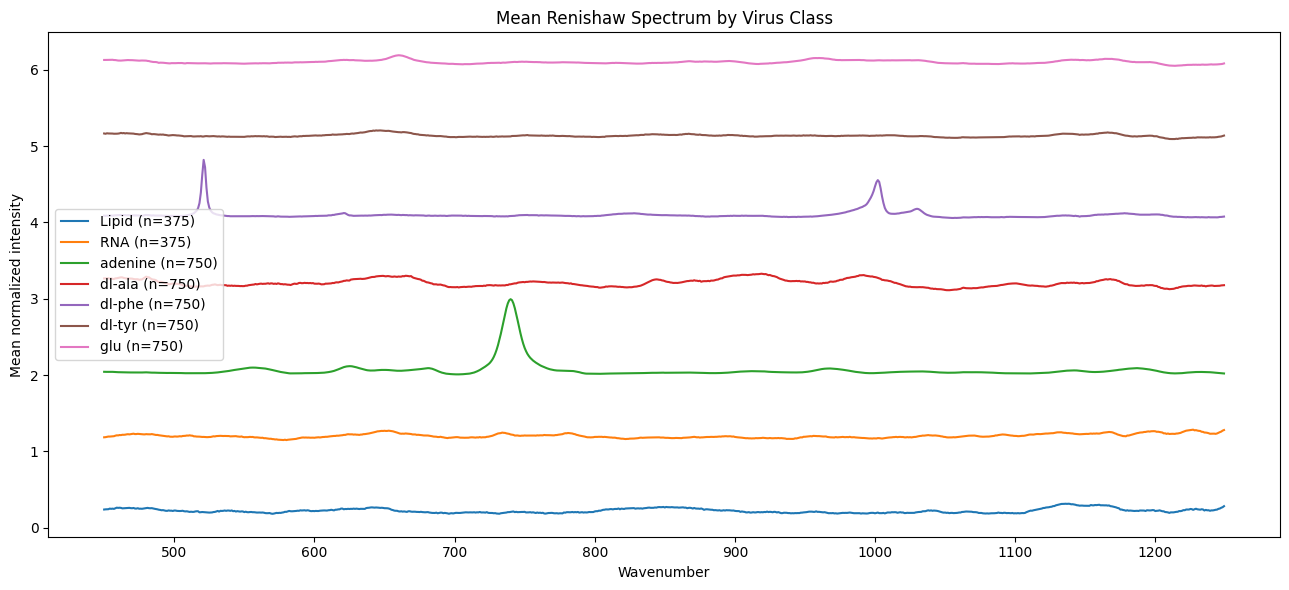

In [47]:
df_plot = horiba_everything.copy()

label_col = "Virus"
metadata_cols = ["Virus", "Subtype", "Strain"]

spectral_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

wavenumbers = np.array(spectral_cols, dtype=float)

class_means = (
    df_plot
    .groupby(label_col)[spectral_cols]
    .mean()
)

plt.figure(figsize=(13, 6))

for i, (virus, row) in enumerate(class_means.iterrows()):
    plt.plot(wavenumbers, row.values+i, label=f"{virus} (n={(df_plot[label_col] == virus).sum()})")

plt.xlabel("Wavenumber")
plt.ylabel("Mean normalized intensity")
plt.title("Mean Renishaw Spectrum by Virus Class")
plt.legend()
plt.tight_layout()
plt.show()

# Transformer-based Domain Adaptation

Use a Raman Transformer as the frozen source classifier inside the cycle-consistent instrument adaptation experiment.


In [45]:
horiba_everything['Virus'].value_counts()

,count
Virus,
adenine,750
dl-ala,750
dl-phe,750
dl-tyr,750
glu,750
RNA,375
Lipid,375


In [46]:
lr=8e-4 # change 1e-3, 4, 5
batch_size=512
dl_n_epochs=40 # change to ~200

In [47]:
class RamanTransformer(nn.Module):
    """Transformer encoder for one-dimensional Raman spectra.

    The spectrum is divided into short contiguous patches. Each patch becomes a
    token, and self-attention learns relationships between peaks anywhere in the
    measured wavenumber range. The public ``features`` method is retained because
    the domain-adaptation section uses classifier embeddings in its feature loss.
    """

    def __init__(
        self,
        n_classes,
        patch_size=16,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        max_patches=128,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model must be divisible by nhead")

        self.patch_size = patch_size
        self.max_patches = max_patches

        # A strided convolution is a learned, non-overlapping spectral patch embedder.
        self.patch_embed = nn.Conv1d(
            1,
            d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, max_patches + 1, d_model)
        )
        self.embedding_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def _tokenize(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        elif x.ndim != 3 or x.shape[1] != 1:
            raise ValueError(
                "Expected shape (batch, length) or (batch, 1, length), "
                f"got {tuple(x.shape)}"
            )

        if x.shape[0] == 0:
            raise ValueError("Input tensor has 0 rows.")

        # Preserve the end of a spectrum when its length is not a patch multiple.
        pad_right = (-x.shape[-1]) % self.patch_size
        if pad_right:
            x = F.pad(x, (0, pad_right), mode="replicate")

        tokens = self.patch_embed(x).transpose(1, 2)
        if tokens.shape[1] > self.max_patches:
            raise ValueError(
                f"Spectrum creates {tokens.shape[1]} patches, but max_patches="
                f"{self.max_patches}. Increase max_patches or patch_size."
            )
        return tokens

    def features(self, x):
        tokens = self._tokenize(x)
        cls = self.cls_token.expand(tokens.shape[0], -1, -1)
        tokens = torch.cat((cls, tokens), dim=1)
        tokens = tokens + self.pos_embedding[:, :tokens.shape[1]]
        encoded = self.encoder(self.embedding_dropout(tokens))
        return encoded[:, 0]

    def forward(self, x):
        return self.classifier(self.features(x))


model = RamanTransformer(n_classes=2)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total number of trainable parameters: {count_parameters(model):,}")


Total number of trainable parameters: 549,250


/tmp/ipykernel_2812/878039201.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [48]:
class Classifier:
    """Portable training wrapper retained for the domain-adaptation section."""

    def __init__(self, n_class, device=None):
        self.device = torch.device(
            device or ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.net = RamanTransformer(n_class).to(self.device)
        self.train_loss = []
        self.val_loss = []

    def fit(self, train_set, train_labels, test_set, test_labels, modelname="raman_transformer"):
        train_x = torch.as_tensor(train_set, dtype=torch.float32)
        train_y = torch.as_tensor(train_labels, dtype=torch.long)
        val_x = torch.as_tensor(test_set, dtype=torch.float32, device=self.device)
        val_y = torch.as_tensor(test_labels, dtype=torch.long, device=self.device)

        train_loader = DataLoader(
            TensorDataset(train_x, train_y),
            batch_size=batch_size,
            shuffle=True,
        )
        optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=lr, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[60, 90], gamma=0.1
        )
        loss_func = nn.CrossEntropyLoss()

        for epoch in range(dl_n_epochs):
            self.net.train()
            running_loss = 0.0
            train_correct = 0
            train_total = 0

            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                optimizer.zero_grad(set_to_none=True)
                logits = self.net(batch_x)
                loss = loss_func(logits, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.net.parameters(), 1.0)
                optimizer.step()

                running_loss += loss.item() * batch_x.shape[0]
                train_correct += (logits.argmax(1) == batch_y).sum().item()
                train_total += batch_y.numel()

            scheduler.step()
            train_loss = running_loss / train_total
            train_acc = train_correct / train_total

            self.net.eval()
            with torch.no_grad():
                val_logits = self.net(val_x)
                val_loss = loss_func(val_logits, val_y).item()
                val_acc = (val_logits.argmax(1) == val_y).float().mean().item()

            self.train_loss.append(train_loss)
            self.val_loss.append(val_loss)
            print(
                f"Epoch {epoch + 1:03d}/{dl_n_epochs} | "
                f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
            )

        torch.save(self.net.state_dict(), f"{modelname}.pt")
        return self

    def predict(self, test_set):
        self.net.eval()
        test_x = torch.as_tensor(test_set, dtype=torch.float32)
        loader = DataLoader(TensorDataset(test_x), batch_size=batch_size, shuffle=False)
        predictions = []
        with torch.no_grad():
            for (batch_x,) in loader:
                logits = self.net(batch_x.to(self.device))
                predictions.append(logits.argmax(1).cpu().numpy())
        return np.concatenate(predictions)

In [49]:
def compute_transformer_feature_importance_per_class(
    model, X, y, wavenumbers, num_classes, max_samples=100, random_state=42
):
    """Mean absolute input-gradient attribution for each Raman class."""
    if X.ndim != 2:
        raise ValueError(f"Expected a 2-D spectral matrix, got shape {X.shape}.")
    if X.shape[1] != len(wavenumbers):
        raise ValueError("The wavenumber axis does not match the spectral width.")

    network = model.net if hasattr(model, "net") else model
    device = next(network.parameters()).device
    network.eval()
    rng = np.random.default_rng(random_state)
    importance = np.zeros((num_classes, X.shape[1]), dtype=np.float32)

    for class_index in range(num_classes):
        indices = np.flatnonzero(y == class_index)
        if len(indices) == 0:
            print(f"Skipping class {class_index}: no samples found.")
            continue
        if len(indices) > max_samples:
            indices = rng.choice(indices, size=max_samples, replace=False)

        inputs = torch.as_tensor(X[indices], dtype=torch.float32, device=device)
        inputs.requires_grad_(True)
        logits = network(inputs)
        selected_score = logits[:, class_index].sum()
        gradients = torch.autograd.grad(selected_score, inputs)[0]
        class_importance = gradients.abs().mean(dim=0).detach().cpu().numpy()
        scale = class_importance.max()
        if scale > 0:
            class_importance /= scale
        importance[class_index] = class_importance

    return importance


# Compatibility alias for any older analysis cells.
compute_cnn_feature_importance_per_class = compute_transformer_feature_importance_per_class

In [50]:
def visualize(frame, label_col="Virus", random_state=42):
    """Plot PCA and t-SNE projections for any prepared spectral dataframe."""
    spectral_cols = get_spectral_columns(frame)
    if label_col not in frame.columns:
        raise ValueError(f"Missing label column: {label_col}")
    if len(frame) < 3:
        raise ValueError("At least three spectra are required for visualization.")

    spectra = frame[spectral_cols].to_numpy(dtype=np.float32)
    labels = frame[label_col].astype(str).reset_index(drop=True)

    pca_result = PCA(n_components=2).fit_transform(spectra)
    perplexity = min(30, max(2, (len(frame) - 1) // 3))
    tsne_result = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(spectra)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label in sorted(labels.unique()):
        mask = labels.eq(label).to_numpy()
        axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1], label=label, alpha=0.45, s=16)
        axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1], label=label, alpha=0.45, s=16)

    axes[0].set(title="PCA of Raman spectra", xlabel="PC1", ylabel="PC2")
    axes[1].set(title="t-SNE of Raman spectra", xlabel="Component 1", ylabel="Component 2")
    for axis in axes:
        axis.grid(alpha=0.25)
    axes[1].legend(title=label_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [51]:
renishaw_train = renishaw_everything.iloc[:, :-2]
horiba_test = horiba_everything.iloc[:, :-2]

In [52]:
label_col = "Virus"
metadata_cols = ["Virus", "Subtype", "Strain"]

# Choose which labels to train on.
# Set to None to use all available classes.
selected_classes = None

# Or specify manually, for example:
# selected_classes = ["adenine", "dl-ala", "dl-phe", "dl-tyr", "glu", "RNA", "Lipid"]

train_val_set = renishaw_train.copy()

if selected_classes is not None:
    train_val_set = train_val_set.loc[
        train_val_set[label_col].isin(selected_classes)
    ].copy()

train_val_set = train_val_set.reset_index(drop=True)

CLASSES = sorted(train_val_set[label_col].dropna().unique().tolist())
CLASSES2IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX2CLASSES = {idx: cls for cls, idx in CLASSES2IDX.items()}

print("Classes:", CLASSES)
print("Class mapping:", CLASSES2IDX)
print(train_val_set[label_col].value_counts())

Classes: ['Lipid', 'RNA', 'adenine', 'dl-ala', 'dl-phe', 'dl-tyr', 'glu']
Class mapping: {'Lipid': 0, 'RNA': 1, 'adenine': 2, 'dl-ala': 3, 'dl-phe': 4, 'dl-tyr': 5, 'glu': 6}
Virus
adenine    750
dl-ala     750
dl-phe     750
dl-tyr     750
glu        750
RNA        375
Lipid      375
Name: count, dtype: int64


In [53]:
spectral_cols = [
    c for c in train_val_set.columns
    if c not in metadata_cols
]

# Optional: keep only numeric spectral columns
spectral_cols = [
    c for c in spectral_cols
    if pd.api.types.is_numeric_dtype(train_val_set[c])
]

In [54]:
max_group_size = 10000

train_val_set = (
    train_val_set.groupby(label_col, group_keys=False)
    .apply(sample_up_to_n, n=max_group_size)
    .reset_index(drop=True)
)

train_val_set_label = np.array([
    CLASSES2IDX[i] for i in train_val_set[label_col]
])

train_val_features = train_val_set[spectral_cols].astype(np.float32).to_numpy()

feature_list = np.array(spectral_cols, dtype=float)

train_set, validate_set, train_labels, validate_labels = train_test_split(
    train_val_features,
    train_val_set_label,
    test_size=0.2,
    random_state=42,
    stratify=train_val_set_label,
)

cnn1d = Classifier(len(CLASSES))

print(
    "train and validate labels:",
    {IDX2CLASSES[value]: count for value, count in zip(*np.unique(train_labels, return_counts=True))},
    {IDX2CLASSES[value]: count for value, count in zip(*np.unique(validate_labels, return_counts=True))}
)

cnn1d.fit(
    train_set,
    train_labels,
    validate_set,
    validate_labels,
    modelname="raman_transformer"
)

start_time = time.time()

/tmp/ipykernel_2812/1865351217.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=max_group_size)
/tmp/ipykernel_2812/878039201.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


train and validate labels: {'Lipid': np.int64(300), 'RNA': np.int64(300), 'adenine': np.int64(600), 'dl-ala': np.int64(600), 'dl-phe': np.int64(600), 'dl-tyr': np.int64(600), 'glu': np.int64(600)} {'Lipid': np.int64(75), 'RNA': np.int64(75), 'adenine': np.int64(150), 'dl-ala': np.int64(150), 'dl-phe': np.int64(150), 'dl-tyr': np.int64(150), 'glu': np.int64(150)}
Epoch 001/40 | train loss 1.8882 | train acc 0.2336 | val loss 1.5862 | val acc 0.3200
Epoch 002/40 | train loss 1.4900 | train acc 0.3981 | val loss 1.5400 | val acc 0.4089
Epoch 003/40 | train loss 1.5020 | train acc 0.4389 | val loss 1.2850 | val acc 0.5267
Epoch 004/40 | train loss 1.2391 | train acc 0.5625 | val loss 1.1935 | val acc 0.5344
Epoch 005/40 | train loss 1.1199 | train acc 0.5964 | val loss 0.9654 | val acc 0.6878
Epoch 006/40 | train loss 0.9405 | train acc 0.6858 | val loss 0.8593 | val acc 0.7033
Epoch 007/40 | train loss 0.8444 | train acc 0.7114 | val loss 0.7586 | val acc 0.7389
Epoch 008/40 | train loss 

In [55]:
class SpectralGenerator(nn.Module):
  def __init__(self, length):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Conv1d(1, 16, 9, padding=4),
        nn.InstanceNorm1d(16),
        nn.ReLU(),
        nn.Conv1d(16, 32, 9, stride=2, padding=4),
        nn.InstanceNorm1d(32),
        nn.ReLU(),
        nn.Conv1d(32, 64, 9, stride=2, padding=4),
        nn.InstanceNorm1d(64),
        nn.ReLU()
    )

    self.body = nn.Sequential(
        nn.Conv1d(64, 64, 7, padding=3),
        nn.InstanceNorm1d(64),
        nn.ReLU(),
        nn.Conv1d(64, 64, 7, padding=3),
        nn.InstanceNorm1d(64),
        nn.ReLU()
    )

    self.decoder = nn.Sequential(
        nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
        nn.Conv1d(64, 32, 9, padding=4),
        nn.InstanceNorm1d(32),
        nn.ReLU(),
        nn.Upsample(scale_factor=2, mode='linear', align_corners=False),
        nn.Conv1d(32, 16, 9, padding=4),
        nn.InstanceNorm1d(16),
        nn.ReLU(),
        nn.Conv1d(16, 1, 9, padding=4),
        nn.Sigmoid()
    )

  def forward(self, x):
    if x.dim() == 2:
      x = x.unsqueeze(1)
    y = self.decoder(self.body(self.encoder(x)))
    return y[..., :x.shape[-1]].squeeze(1)

In [56]:
class PatchDiscriminator1D(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv1d(1, 32, 11, stride=2, padding=5),
        nn.LeakyReLU(0.2),
        nn.Conv1d(32, 64, 11, stride=2, padding=5),
        nn.InstanceNorm1d(64),
        nn.LeakyReLU(0.2),
        nn.Conv1d(64, 128, 11, stride=2, padding=5),
        nn.InstanceNorm1d(128),
        nn.LeakyReLU(0.2),
        nn.Conv1d(128, 1, 7, padding=3)
    )

  def forward(self, x):
    if x.dim() == 2:
      x = x.unsqueeze(1)
    return self.net(x)

In [57]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device {device}")

source_model = cnn1d.net.to(device)
source_model.eval()

for p in source_model.parameters():
  p.requires_grad = False

Using device cuda


In [62]:
spectral_cols = sorted(
    set(get_spectral_columns(renishaw_train)).intersection(
        get_spectral_columns(horiba_test)
    ),
    key=float,
)
if not spectral_cols:
    raise ValueError("Renishaw and Horiba have no shared spectral columns.")

source_frame = renishaw_train.loc[renishaw_train["Virus"].isin(CLASSES)].copy()
target_frame = horiba_test.loc[horiba_test["Virus"].isin(CLASSES)].copy()

source_x = source_frame[spectral_cols].to_numpy(dtype=np.float32)
source_y = source_frame["Virus"].map(CLASSES2IDX).to_numpy(dtype=np.int64)
target_x = target_frame[spectral_cols].to_numpy(dtype=np.float32)

source_ds = TensorDataset(
    torch.tensor(source_x, dtype=torch.float32),
    torch.tensor(source_y, dtype=torch.long),
)
target_ds = TensorDataset(torch.tensor(target_x, dtype=torch.float32))

source_loader = DataLoader(source_ds, batch_size=32, shuffle=True, drop_last=True)
target_loader = DataLoader(target_ds, batch_size=32, shuffle=True, drop_last=True)

if len(source_loader) == 0 or len(target_loader) == 0:
    raise ValueError("Domain adaptation requires at least one full batch per instrument.")

In [63]:
length = len(spectral_cols)
G_ST = SpectralGenerator(length).to(device)
G_TS = SpectralGenerator(length).to(device)
D_S = PatchDiscriminator1D().to(device)
D_T = PatchDiscriminator1D().to(device)

mse = nn.MSELoss()
ce = nn.CrossEntropyLoss()

opt_G = torch.optim.Adam(
    list(G_ST.parameters()) + list(G_TS.parameters()),
    lr=5e-4,
    betas=(0.5, 0.999)
)

opt_D = torch.optim.Adam(
    list(D_T.parameters()) + list(D_S.parameters()),
    lr=5e-4,
    betas=(0.5, 0.999)
)

In [64]:
history = {
    "G": [],
    "D": [],
    "adv": [],
    "cycle": [],
    "identity": [],
    "semantic": [],
    "feature": [],
    "fake_tgt_cls_acc": [],
    "D_T_real": [],
    "D_T_fake": [],
    "D_S_real": [],
    "D_S_fake": [],
}

n_epochs = 50

lambda_cycle = 1.0
lambda_identity = 0.1
lambda_semantic = 0.5
lambda_feature = 0.1

for epoch in range(n_epochs):

  epoch_logs = {k: 0.0 for k in history}
  num_batches = min(len(source_loader), len(target_loader))

  G_ST.train()
  G_TS.train()
  D_S.train()
  D_T.train()
  source_model.eval()

  for (src_x, src_y), (tgt_x,) in zip(source_loader, target_loader):
    src_x = src_x.to(device)
    src_y = src_y.to(device)
    tgt_x = tgt_x.to(device)

    # Train generators

    fake_tgt = G_ST(src_x)
    fake_src = G_TS(tgt_x)

    rec_tgt = G_ST(fake_src)
    rec_src = G_TS(fake_tgt)

    id_tgt = G_ST(tgt_x)
    id_src = G_TS(src_x)

    pred_fake_tgt = D_T(fake_tgt)
    pred_fake_src = D_S(fake_src)

    loss_adv = (
        mse(pred_fake_tgt, torch.ones_like(pred_fake_tgt)) +
        mse(pred_fake_src, torch.ones_like(pred_fake_src))
    )

    loss_cycle = mse(rec_src, src_x) + mse(rec_tgt, tgt_x)

    loss_identity = mse(id_src, src_x) + mse(id_tgt, tgt_x)

    logits_fake_tgt = source_model(fake_tgt)
    loss_semantic = ce(logits_fake_tgt, src_y)

    feat_src = source_model.features(src_x)
    feat_fake_tgt = source_model.features(fake_tgt)
    loss_feature = mse(feat_fake_tgt, feat_src)

    loss_G = (
        loss_adv
        + lambda_cycle * loss_cycle
        + lambda_identity * loss_identity
        + lambda_semantic * loss_semantic
        + lambda_feature * loss_feature
    )

    opt_G.zero_grad()
    loss_G.backward()
    torch.nn.utils.clip_grad_norm_(list(G_ST.parameters()) + list(G_TS.parameters()), 1.0)
    opt_G.step()

    with torch.no_grad():
      fake_tgt = G_ST(src_x)
      fake_src = G_TS(tgt_x)

    real_tgt_pred = D_T(tgt_x)
    fake_tgt_pred = D_T(fake_tgt.detach())

    real_src_pred = D_S(src_x)
    fake_src_pred = D_S(fake_src.detach())

    loss_D_T = 0.5 * (
        mse(real_tgt_pred, torch.ones_like(real_tgt_pred)) +
        mse(fake_tgt_pred, torch.zeros_like(fake_tgt_pred))
    )

    loss_D_S = 0.5 * (
        mse(real_src_pred, torch.ones_like(real_src_pred)) +
        mse(fake_src_pred, torch.zeros_like(fake_src_pred))
    )

    loss_D = loss_D_T + loss_D_S

    opt_D.zero_grad()
    loss_D.backward()
    torch.nn.utils.clip_grad_norm_(list(D_T.parameters()) + list(D_S.parameters()), 1.0)
    opt_D.step()

    with torch.no_grad():
      fake_tgt_pred_labels = torch.argmax(logits_fake_tgt, dim=1)
      fake_tgt_cls_acc = (fake_tgt_pred_labels == src_y).float().mean()

    epoch_logs["G"] += loss_G.item()
    epoch_logs["D"] += loss_D.item()
    epoch_logs["adv"] += loss_adv.item()
    epoch_logs["cycle"] += loss_cycle.item()
    epoch_logs["identity"] += loss_identity.item()
    epoch_logs["semantic"] += loss_semantic.item()
    epoch_logs["feature"] += loss_feature.item()
    epoch_logs["fake_tgt_cls_acc"] += fake_tgt_cls_acc.item()
    epoch_logs["D_T_real"] += real_tgt_pred.mean().item()
    epoch_logs["D_T_fake"] += fake_tgt_pred.mean().item()
    epoch_logs["D_S_real"] += real_src_pred.mean().item()
    epoch_logs["D_S_fake"] += fake_src_pred.mean().item()

  for k in history:
    history[k].append(epoch_logs[k] / num_batches)

  print(
      f"Epoch {epoch + 1}/{n_epochs} | "
      f"G: {history['G'][-1]:.4f} | "
      f"D: {history['D'][-1]:.4f} | "
      f"Cycle: {history['cycle'][-1]:.4f} | "
      f"Semantic: {history['semantic'][-1]:.4f} | "
      f"Feature: {history['feature'][-1]:.4f} | "
      f"FakeTgtClsAcc: {history['fake_tgt_cls_acc'][-1]:.2%}"
  )


Epoch 1/50 | G: 1.8051 | D: 0.3803 | Cycle: 0.0562 | Semantic: 1.2972 | Feature: 0.7507 | FakeTgtClsAcc: 71.00%
Epoch 2/50 | G: 1.2290 | D: 0.3614 | Cycle: 0.0341 | Semantic: 0.2920 | Feature: 0.3605 | FakeTgtClsAcc: 90.87%
Epoch 3/50 | G: 1.1616 | D: 0.3607 | Cycle: 0.0330 | Semantic: 0.2336 | Feature: 0.2652 | FakeTgtClsAcc: 92.63%
Epoch 4/50 | G: 1.0213 | D: 0.4075 | Cycle: 0.0341 | Semantic: 0.2248 | Feature: 0.2642 | FakeTgtClsAcc: 92.99%
Epoch 5/50 | G: 0.9480 | D: 0.4268 | Cycle: 0.0335 | Semantic: 0.2059 | Feature: 0.2353 | FakeTgtClsAcc: 93.55%
Epoch 6/50 | G: 0.8884 | D: 0.4333 | Cycle: 0.0338 | Semantic: 0.1561 | Feature: 0.2220 | FakeTgtClsAcc: 94.82%
Epoch 7/50 | G: 0.8869 | D: 0.4300 | Cycle: 0.0352 | Semantic: 0.1485 | Feature: 0.2190 | FakeTgtClsAcc: 95.31%
Epoch 8/50 | G: 0.8980 | D: 0.4286 | Cycle: 0.0350 | Semantic: 0.1400 | Feature: 0.2075 | FakeTgtClsAcc: 95.25%
Epoch 9/50 | G: 0.8531 | D: 0.4336 | Cycle: 0.0325 | Semantic: 0.1195 | Feature: 0.2069 | FakeTgtClsAcc:

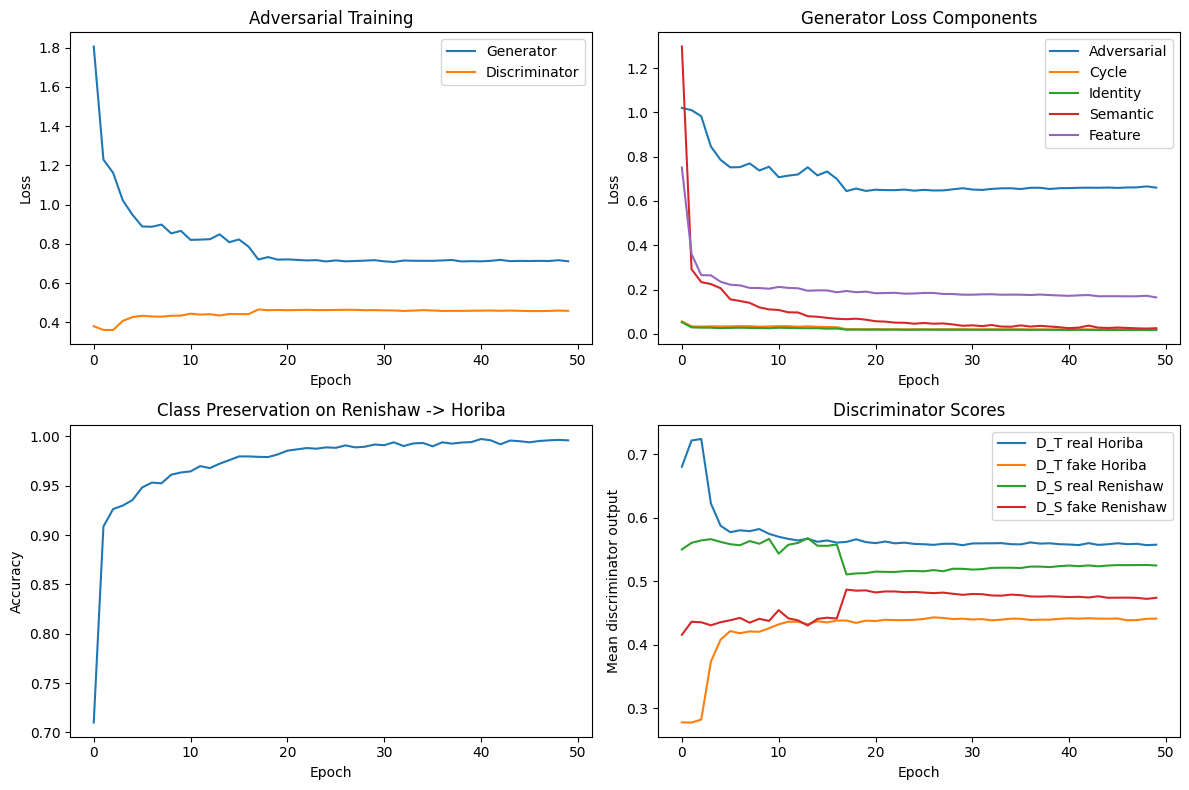

In [65]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(history["G"], label="Generator")
plt.plot(history["D"], label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adversarial Training")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history["adv"], label="Adversarial")
plt.plot(history["cycle"], label="Cycle")
plt.plot(history["identity"], label="Identity")
plt.plot(history["semantic"], label="Semantic")
plt.plot(history["feature"], label="Feature")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Generator Loss Components")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(history["fake_tgt_cls_acc"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Class Preservation on Renishaw -> Horiba")

plt.subplot(2, 2, 4)
plt.plot(history["D_T_real"], label="D_T real Horiba")
plt.plot(history["D_T_fake"], label="D_T fake Horiba")
plt.plot(history["D_S_real"], label="D_S real Renishaw")
plt.plot(history["D_S_fake"], label="D_S fake Renishaw")
plt.xlabel("Epoch")
plt.ylabel("Mean discriminator output")
plt.title("Discriminator Scores")
plt.legend()

plt.tight_layout()
plt.show()

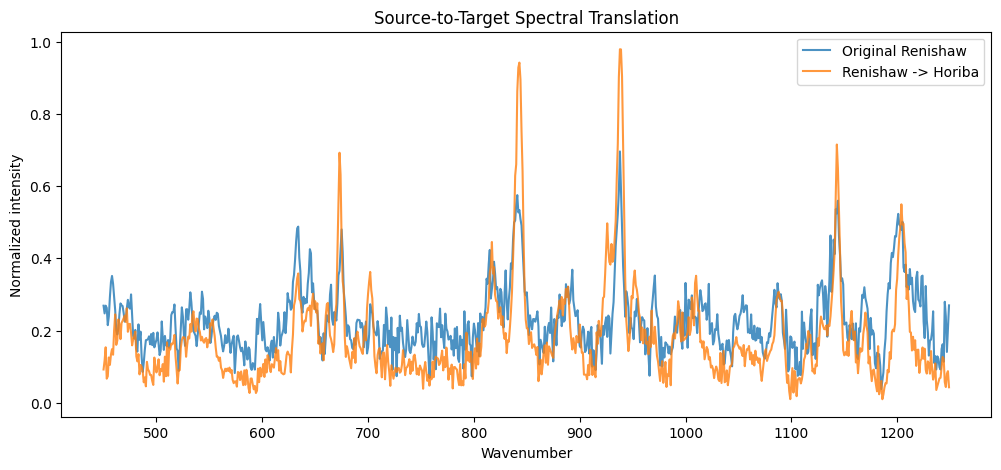

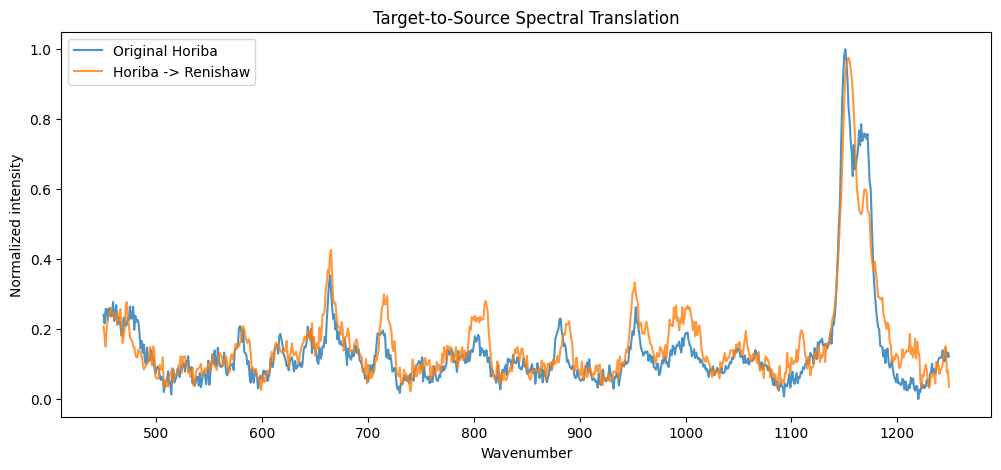

In [66]:
G_ST.eval()
G_TS.eval()

src_batch, src_labels = next(iter(source_loader))
tgt_batch, = next(iter(target_loader))

src_batch = src_batch.to(device)
tgt_batch = tgt_batch.to(device)

with torch.no_grad():
    src_to_tgt = G_ST(src_batch).cpu().numpy()
    tgt_to_src = G_TS(tgt_batch).cpu().numpy()
    src_np = src_batch.cpu().numpy()
    tgt_np = tgt_batch.cpu().numpy()

wavenumbers = np.array(spectral_cols, dtype=float)

i = 0

plt.figure(figsize=(12, 5))
plt.plot(wavenumbers, src_np[i], label="Original Renishaw", alpha=0.8)
plt.plot(wavenumbers, src_to_tgt[i], label="Renishaw -> Horiba", alpha=0.8)
plt.xlabel("Wavenumber")
plt.ylabel("Normalized intensity")
plt.title("Source-to-Target Spectral Translation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(wavenumbers, tgt_np[i], label="Original Horiba", alpha=0.8)
plt.plot(wavenumbers, tgt_to_src[i], label="Horiba -> Renishaw", alpha=0.8)
plt.xlabel("Wavenumber")
plt.ylabel("Normalized intensity")
plt.title("Target-to-Source Spectral Translation")
plt.legend()
plt.show()

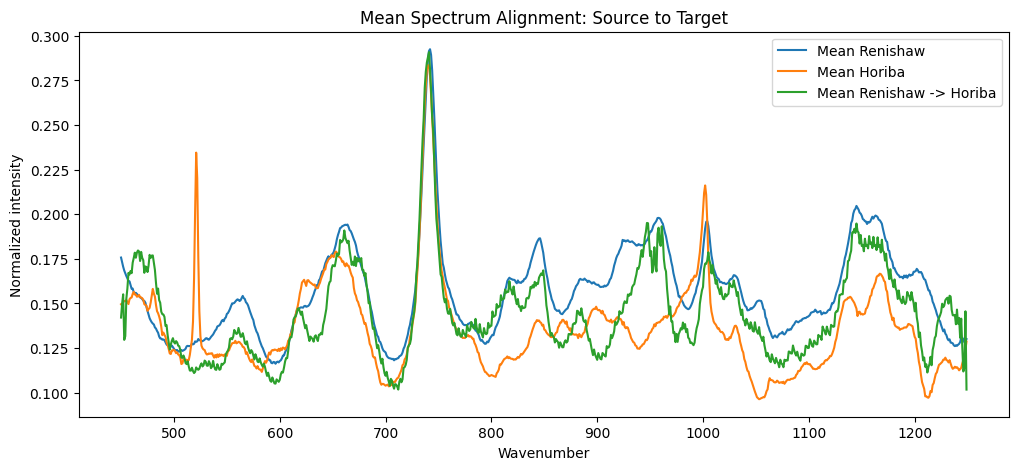

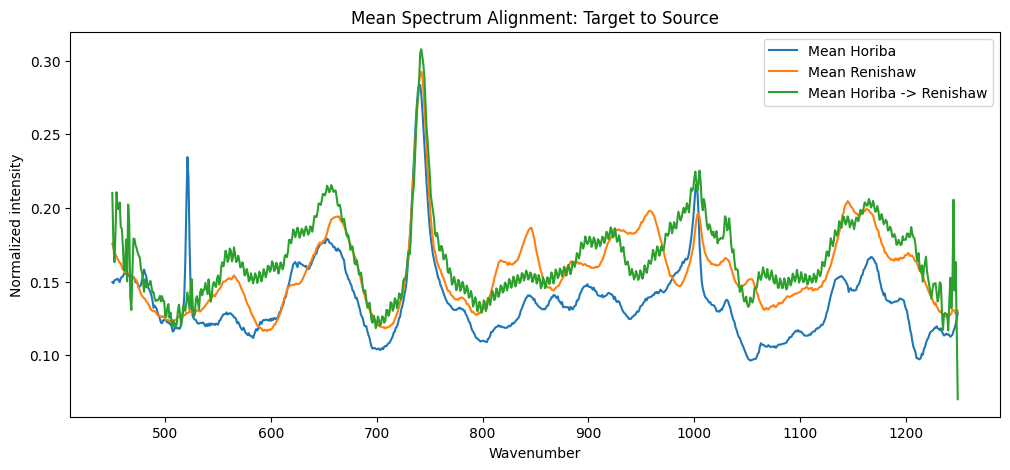

In [67]:
with torch.no_grad():
    source_tensor = torch.tensor(source_x, dtype=torch.float32).to(device)
    target_tensor = torch.tensor(target_x, dtype=torch.float32).to(device)

    source_as_target = G_ST(source_tensor).cpu().numpy()
    target_as_source = G_TS(target_tensor).cpu().numpy()

plt.figure(figsize=(12, 5))
plt.plot(wavenumbers, source_x.mean(axis=0), label="Mean Renishaw")
plt.plot(wavenumbers, target_x.mean(axis=0), label="Mean Horiba")
plt.plot(wavenumbers, source_as_target.mean(axis=0), label="Mean Renishaw -> Horiba")
plt.xlabel("Wavenumber")
plt.ylabel("Normalized intensity")
plt.title("Mean Spectrum Alignment: Source to Target")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(wavenumbers, target_x.mean(axis=0), label="Mean Horiba")
plt.plot(wavenumbers, source_x.mean(axis=0), label="Mean Renishaw")
plt.plot(wavenumbers, target_as_source.mean(axis=0), label="Mean Horiba -> Renishaw")
plt.xlabel("Wavenumber")
plt.ylabel("Normalized intensity")
plt.title("Mean Spectrum Alignment: Target to Source")
plt.legend()
plt.show()

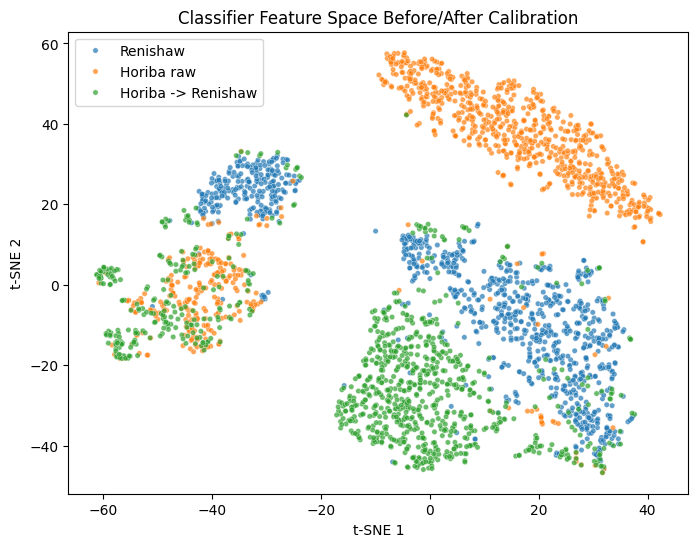

In [68]:
source_model.eval()
G_TS.eval()

n_vis = min(1000, len(source_x), len(target_x))

src_vis = torch.tensor(source_x[:n_vis], dtype=torch.float32).to(device)
tgt_vis = torch.tensor(target_x[:n_vis], dtype=torch.float32).to(device)

with torch.no_grad():
    src_feat = source_model.features(src_vis).cpu().numpy()
    tgt_feat = source_model.features(tgt_vis).cpu().numpy()
    tgt_cal_feat = source_model.features(G_TS(tgt_vis)).cpu().numpy()

features = np.vstack([src_feat, tgt_feat, tgt_cal_feat])
domains = (
    ["Renishaw"] * n_vis +
    ["Horiba raw"] * n_vis +
    ["Horiba -> Renishaw"] * n_vis
)

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
emb = tsne.fit_transform(features)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=domains, s=15, alpha=0.7)
plt.title("Classifier Feature Space Before/After Calibration")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.show()

In [69]:
from sklearn.metrics import classification_report

G_TS.eval()
source_model.eval()

with torch.no_grad():
    horiba_x_tensor = torch.tensor(target_x, dtype=torch.float32).to(device)
    horiba_as_renishaw = G_TS(horiba_x_tensor)
    logits = source_model(horiba_as_renishaw)
    pred_adapted = torch.argmax(logits, dim=1).cpu().numpy()

horiba_y = np.array([CLASSES2IDX[v] for v in horiba_test["Virus"]])

print(classification_report(
    horiba_y,
    pred_adapted,
    labels=list(range(len(CLASSES))),
    target_names=CLASSES,
    zero_division=0,
))

              precision    recall  f1-score   support

       Lipid       0.15      0.65      0.24       375
         RNA       0.26      0.44      0.32       375
     adenine       1.00      1.00      1.00       750
      dl-ala       0.62      0.29      0.40       750
      dl-phe       0.01      0.01      0.01       750
      dl-tyr       0.20      0.06      0.09       750
         glu       0.58      0.30      0.39       750

    accuracy                           0.37      4500
   macro avg       0.40      0.39      0.35      4500
weighted avg       0.43      0.37      0.36      4500



In [70]:
G_TS.eval()
source_model.eval()

horiba_x_tensor = torch.tensor(target_x, dtype=torch.float32).to(device)

with torch.no_grad():
    horiba_as_renishaw = G_TS(horiba_x_tensor)
    logits = source_model(horiba_as_renishaw)
    predicted_labels_adapted = torch.argmax(logits, dim=1).cpu().numpy()

In [71]:
horiba_y = np.array([CLASSES2IDX[v] for v in horiba_test["Virus"]])

acc = accuracy_score(horiba_y, predicted_labels_adapted)
print(f"Adapted Horiba accuracy: {acc:.2%}")

Adapted Horiba accuracy: 36.60%


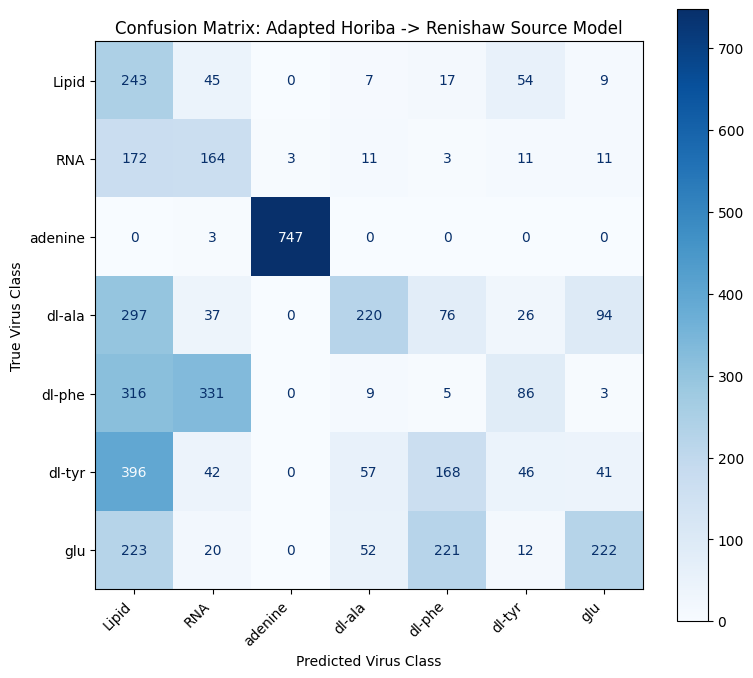

In [72]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    horiba_y,
    pred_adapted,
    labels=list(range(len(CLASSES)))
)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title("Confusion Matrix: Adapted Horiba -> Renishaw Source Model")
ax.set_xlabel("Predicted Virus Class")
ax.set_ylabel("True Virus Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Simplified Raman Transformer Classifier

Train a patch-based Transformer encoder on Renishaw spectra and evaluate cross-instrument generalization on Horiba spectra.


In [73]:
# -----------------------
# Parameters
# -----------------------
lr = 8e-4
batch_size = 512
dl_n_epochs = 50
max_group_size = 10000
test_size = 0.2
random_state = 42

label_col = "Virus"
modelname = "raman_transformer"

# Optional filtering:
# Set to None to use every class present in label_col.
selected_classes = None
# Example:
# selected_classes = ["adenine", "dl-ala", "dl-phe", "dl-tyr", "glu", "RNA", "Lipid"]

In [74]:
renishaw_train = sampled_renishaw
horiba_test = sampled_horiba

In [75]:
import time
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split


class RamanTransformer(nn.Module):
    """Transformer encoder for one-dimensional Raman spectra.

    The spectrum is divided into short contiguous patches. Each patch becomes a
    token, and self-attention learns relationships between peaks anywhere in the
    measured wavenumber range. The public ``features`` method is retained because
    the domain-adaptation section uses classifier embeddings in its feature loss.
    """

    def __init__(
        self,
        n_classes,
        patch_size=16,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        max_patches=128,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model must be divisible by nhead")

        self.patch_size = patch_size
        self.max_patches = max_patches

        # A strided convolution is a learned, non-overlapping spectral patch embedder.
        self.patch_embed = nn.Conv1d(
            1,
            d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, max_patches + 1, d_model)
        )
        self.embedding_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def _tokenize(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        elif x.ndim != 3 or x.shape[1] != 1:
            raise ValueError(
                "Expected shape (batch, length) or (batch, 1, length), "
                f"got {tuple(x.shape)}"
            )

        if x.shape[0] == 0:
            raise ValueError("Input tensor has 0 rows.")

        # Preserve the end of a spectrum when its length is not a patch multiple.
        pad_right = (-x.shape[-1]) % self.patch_size
        if pad_right:
            x = F.pad(x, (0, pad_right), mode="replicate")

        tokens = self.patch_embed(x).transpose(1, 2)
        if tokens.shape[1] > self.max_patches:
            raise ValueError(
                f"Spectrum creates {tokens.shape[1]} patches, but max_patches="
                f"{self.max_patches}. Increase max_patches or patch_size."
            )
        return tokens

    def features(self, x):
        tokens = self._tokenize(x)
        cls = self.cls_token.expand(tokens.shape[0], -1, -1)
        tokens = torch.cat((cls, tokens), dim=1)
        tokens = tokens + self.pos_embedding[:, :tokens.shape[1]]
        encoded = self.encoder(self.embedding_dropout(tokens))
        return encoded[:, 0]

    def forward(self, x):
        return self.classifier(self.features(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# -----------------------
# Build train/validation data
# -----------------------
if selected_classes is None:
    classes = sorted(renishaw_train[label_col].dropna().unique())
else:
    classes = selected_classes

class_to_idx = {label: idx for idx, label in enumerate(classes)}
idx_to_class = {idx: label for label, idx in class_to_idx.items()}

train_val_set = (
    renishaw_train
    .loc[renishaw_train[label_col].isin(classes)]
    .copy()
    .reset_index(drop=True)
)

print("Counts before sampling:")
print(train_val_set[label_col].value_counts())

train_val_set = (
    train_val_set
    .sample(frac=1, random_state=random_state)
    .groupby(label_col, group_keys=False, sort=False)
    .head(max_group_size)
    .reset_index(drop=True)
)

print("Counts after sampling:")
print(train_val_set[label_col].value_counts())

train_val_labels = train_val_set[label_col].map(class_to_idx).to_numpy()

feature_cols = []
for col in train_val_set.columns:
    if col == label_col:
        continue
    try:
        float(col)
        feature_cols.append(col)
    except ValueError:
        pass

train_val_features = train_val_set[feature_cols].astype(np.float32).to_numpy()
feature_list = np.array(feature_cols, dtype=float)

train_set, validate_set, train_labels, validate_labels = train_test_split(
    train_val_features,
    train_val_labels,
    test_size=test_size,
    random_state=random_state,
    stratify=train_val_labels,
)

print("Validation label counts:")
print(pd.Series(validate_labels).map(idx_to_class).value_counts())

# -----------------------
# Create model
# -----------------------
n_classes = len(classes)
model = RamanTransformer(n_classes=n_classes)

print(f"Classes: {classes}")
print(f"Number of classes: {n_classes}")
print(f"Total trainable parameters: {count_parameters(model):,}")

class Classifier:
    def __init__(
        self,
        n_classes,
        lr=8e-4,
        batch_size=512,
        n_epochs=200,
        device=None,
    ):
        self.n_classes = n_classes
        self.lr = lr
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.net = RamanTransformer(n_classes=n_classes).to(self.device)
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.net.parameters(), lr=self.lr)

        self.history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
        }

    def fit(self, train_x, train_y, validate_x, validate_y, modelname="RamanTransformer"):
        train_x = torch.tensor(train_x, dtype=torch.float32).to(self.device)
        train_y = torch.tensor(train_y, dtype=torch.long).to(self.device)
        validate_x = torch.tensor(validate_x, dtype=torch.float32).to(self.device)
        validate_y = torch.tensor(validate_y, dtype=torch.long).to(self.device)

        train_dataset = torch.utils.data.TensorDataset(train_x, train_y)
        train_loader = torch.utils.data.DataLoader(
            train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
        )

        for epoch in range(self.n_epochs):
            self.net.train()
            train_loss = 0.0
            correct = 0
            total = 0

            for batch_x, batch_y in train_loader:
                self.optimizer.zero_grad()

                logits = self.net(batch_x)
                loss = self.criterion(logits, batch_y)

                loss.backward()
                self.optimizer.step()

                train_loss += loss.item() * batch_x.size(0)
                preds = logits.argmax(dim=1)
                correct += (preds == batch_y).sum().item()
                total += batch_y.size(0)

            train_loss /= total
            train_acc = correct / total

            self.net.eval()
            with torch.no_grad():
                val_logits = self.net(validate_x)
                val_loss = self.criterion(val_logits, validate_y).item()
                val_preds = val_logits.argmax(dim=1)
                val_acc = (val_preds == validate_y).float().mean().item()

            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)

            print(
                f"Epoch {epoch + 1:03d}/{self.n_epochs} | "
                f"train loss: {train_loss:.4f} | "
                f"train acc: {train_acc:.4f} | "
                f"val loss: {val_loss:.4f} | "
                f"val acc: {val_acc:.4f}"
            )

        torch.save(self.net.state_dict(), f"{modelname}.pt")
        return self

    def predict(self, x):
        self.net.eval()

        x = torch.tensor(x, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            logits = self.net(x)
            preds = logits.argmax(dim=1)

        return preds.cpu().numpy()

    def predict_proba(self, x):
        self.net.eval()

        x = torch.tensor(x, dtype=torch.float32).to(self.device)

        with torch.no_grad():
            logits = self.net(x)
            probs = torch.softmax(logits, dim=1)

        return probs.cpu().numpy()

    def plot_training_metrics(self):
        epochs = np.arange(1, len(self.history["train_loss"]) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(13, 5))

        axes[0].plot(epochs, self.history["train_loss"], label="Train")
        axes[0].plot(epochs, self.history["val_loss"], label="Validation")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Cross-entropy loss")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(epochs, self.history["train_acc"], label="Train")
        axes[1].plot(epochs, self.history["val_acc"], label="Validation")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_classification_results(self, x, y_true, idx_to_class=None, normalize=True):
        y_pred = self.predict(x)

        labels = sorted(np.unique(y_true))
        class_names = [
            idx_to_class[i] if idx_to_class is not None else str(i)
            for i in labels
        ]

        acc = accuracy_score(y_true, y_pred)
        print(f"Accuracy: {acc:.4f}")
        print()
        print(
            classification_report(
                y_true,
                y_pred,
                labels=labels,
                target_names=class_names,
                zero_division=0,
            )
        )

        cm = confusion_matrix(y_true, y_pred, labels=labels)

        if normalize:
            cm_to_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_to_plot = np.nan_to_num(cm_to_plot)
            fmt = ".2f"
            title = "Normalized Confusion Matrix"
        else:
            cm_to_plot = cm
            fmt = "d"
            title = "Confusion Matrix"

        plt.figure(figsize=(8, 7))
        sns.heatmap(
            cm_to_plot,
            annot=True,
            fmt=fmt,
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            square=True,
        )
        plt.title(title)
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.tight_layout()
        plt.show()

        return y_pred

cnn1d = Classifier(
    n_classes=n_classes,
    lr=lr,
    batch_size=batch_size,
    n_epochs=dl_n_epochs,
)

print(
    "train and validate labels:",
    dict(zip(*np.unique(train_labels, return_counts=True))),
    dict(zip(*np.unique(validate_labels, return_counts=True))),
)

start_time = time.time()

cnn1d.fit(
    train_set,
    train_labels,
    validate_set,
    validate_labels,
    modelname=modelname,
)

Counts before sampling:
Virus
FluB    750
IBV     750
Name: count, dtype: int64
Counts after sampling:
Virus
IBV     750
FluB    750
Name: count, dtype: int64
Validation label counts:
FluB    150
IBV     150
Name: count, dtype: int64
Classes: ['FluB', 'IBV']
Number of classes: 2
Total trainable parameters: 549,250
train and validate labels: {np.int64(0): np.int64(600), np.int64(1): np.int64(600)} {np.int64(0): np.int64(150), np.int64(1): np.int64(150)}


/tmp/ipykernel_2812/3072570487.py:59: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001/50 | train loss: 1.2219 | train acc: 0.5117 | val loss: 0.7465 | val acc: 0.5000
Epoch 002/50 | train loss: 0.7495 | train acc: 0.5008 | val loss: 0.8528 | val acc: 0.5000
Epoch 003/50 | train loss: 0.8321 | train acc: 0.5000 | val loss: 0.7204 | val acc: 0.5000
Epoch 004/50 | train loss: 0.7067 | train acc: 0.5158 | val loss: 0.7134 | val acc: 0.5000
Epoch 005/50 | train loss: 0.7291 | train acc: 0.5058 | val loss: 0.7359 | val acc: 0.5000
Epoch 006/50 | train loss: 0.7280 | train acc: 0.4958 | val loss: 0.6979 | val acc: 0.5000
Epoch 007/50 | train loss: 0.6980 | train acc: 0.5083 | val loss: 0.6987 | val acc: 0.5000
Epoch 008/50 | train loss: 0.7143 | train acc: 0.4883 | val loss: 0.7097 | val acc: 0.5000
Epoch 009/50 | train loss: 0.7191 | train acc: 0.4975 | val loss: 0.6982 | val acc: 0.5000
Epoch 010/50 | train loss: 0.6996 | train acc: 0.4992 | val loss: 0.6927 | val acc: 0.5000
Epoch 011/50 | train loss: 0.6976 | train acc: 0.5183 | val loss: 0.6956 | val acc: 0.5000

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

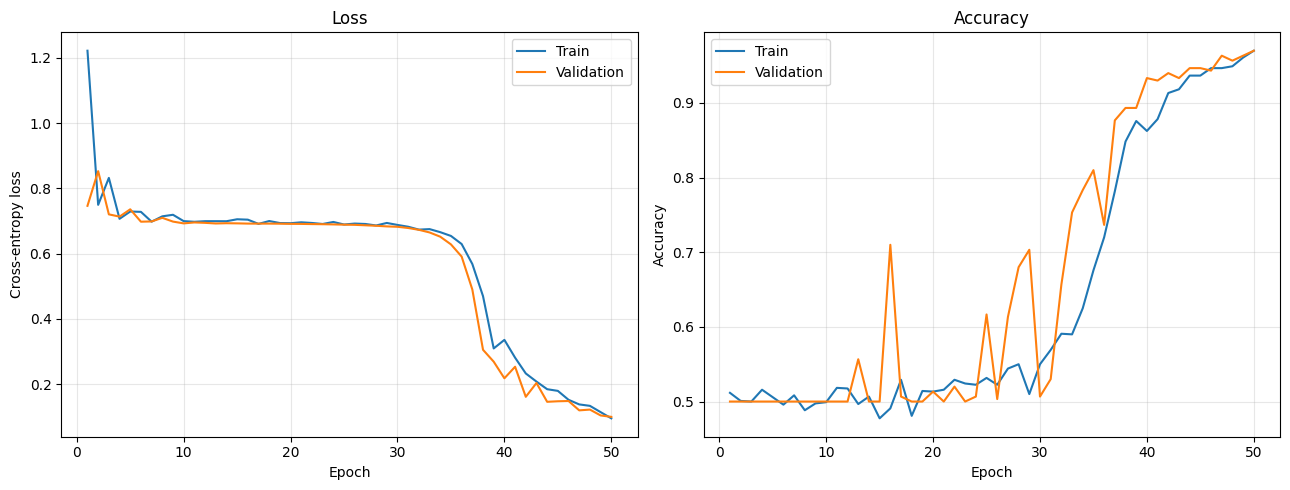

Accuracy: 0.9700

              precision    recall  f1-score   support

        FluB       0.98      0.96      0.97       150
         IBV       0.96      0.98      0.97       150

    accuracy                           0.97       300
   macro avg       0.97      0.97      0.97       300
weighted avg       0.97      0.97      0.97       300



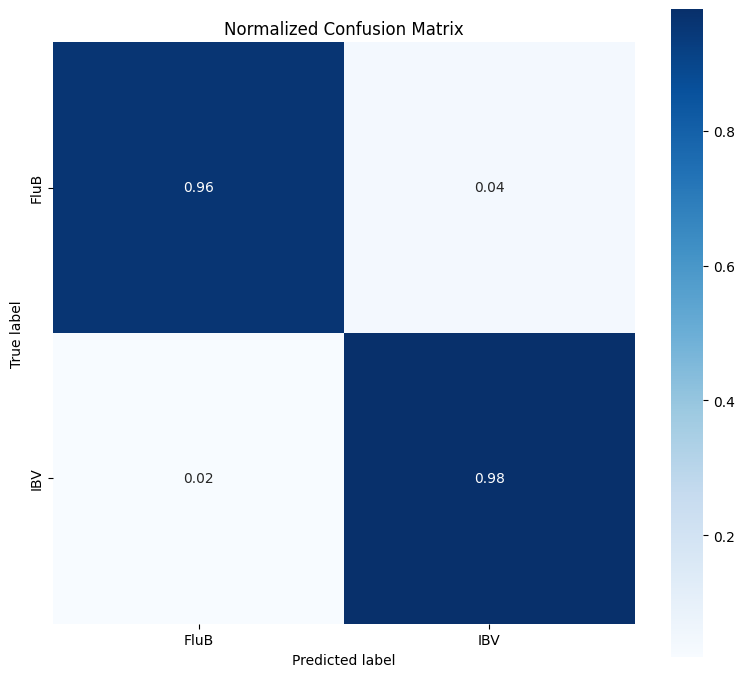

In [77]:
cnn1d.plot_training_metrics()

validate_preds = cnn1d.plot_classification_results(
    validate_set,
    validate_labels,
    idx_to_class=idx_to_class,
    normalize=True,
)

test labels: {np.int64(0): np.int64(750), np.int64(1): np.int64(750)}
Accuracy: 0.7900

              precision    recall  f1-score   support

        FluB       0.71      0.97      0.82       750
         IBV       0.95      0.61      0.75       750

    accuracy                           0.79      1500
   macro avg       0.83      0.79      0.78      1500
weighted avg       0.83      0.79      0.78      1500



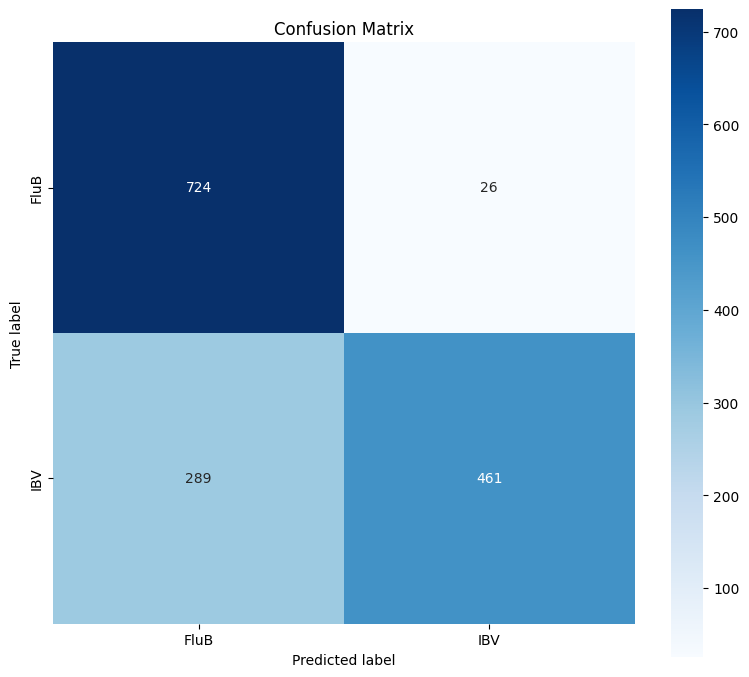

In [78]:
# -----------------------
# Test on horiba_test
# -----------------------
test_set = horiba_test.loc[horiba_test[label_col].isin(classes)].copy().reset_index(drop=True)

test_labels = test_set[label_col].map(class_to_idx).to_numpy()
test_features = test_set[feature_cols].astype(np.float32).to_numpy()

print("test labels:", dict(zip(*np.unique(test_labels, return_counts=True))))

test_preds = cnn1d.plot_classification_results(
    test_features,
    test_labels,
    idx_to_class=idx_to_class,
    normalize=False,
)

In [79]:
def plot_spectra_comparison(
    source_frame,
    target_frame,
    label_col="Virus",
    target_class="dl-ala",
    alpha=0.08,
):
    """Compare the same Raman class across the two instruments."""
    source_cols = get_spectral_columns(source_frame)
    target_cols = get_spectral_columns(target_frame)
    common_cols = sorted(set(source_cols).intersection(target_cols), key=float)
    if not common_cols:
        raise ValueError("No shared spectral columns were found between instruments.")

    wavenumbers = np.asarray(common_cols, dtype=float)
    source_spectra = source_frame.loc[
        source_frame[label_col] == target_class, common_cols
    ].to_numpy(dtype=float)
    target_spectra = target_frame.loc[
        target_frame[label_col] == target_class, common_cols
    ].to_numpy(dtype=float)
    if len(source_spectra) == 0 or len(target_spectra) == 0:
        raise ValueError(f"Class {target_class!r} must exist in both instruments.")

    source_mean = source_spectra.mean(axis=0)
    target_mean = target_spectra.mean(axis=0)
    fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

    for spectrum in source_spectra:
        axes[0].plot(wavenumbers, spectrum, color="tab:blue", alpha=alpha, linewidth=0.7)
    for spectrum in target_spectra:
        axes[0].plot(wavenumbers, spectrum, color="tab:orange", alpha=alpha, linewidth=0.7)
    axes[0].plot(wavenumbers, source_mean, color="blue", linewidth=2.5, label="Renishaw mean")
    axes[0].plot(wavenumbers, target_mean, color="darkorange", linewidth=2.5, label="Horiba mean")
    axes[0].set_title(f"{target_class}: individual spectra and instrument means")
    axes[0].set_ylabel("Normalized intensity")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    combined = np.vstack([source_spectra, target_spectra])
    axes[1].imshow(
        combined,
        aspect="auto",
        cmap="viridis",
        extent=[wavenumbers.min(), wavenumbers.max(), combined.shape[0], 0],
    )
    axes[1].axhline(len(source_spectra), color="white", linewidth=2)
    axes[1].set_title("Renishaw rows followed by Horiba rows")
    axes[1].set_ylabel("Spectrum index")

    axes[2].plot(wavenumbers, source_mean - target_mean, color="black", linewidth=1.8)
    axes[2].axhline(0, color="gray", linestyle="--", linewidth=1)
    axes[2].set_title("Mean difference: Renishaw − Horiba")
    axes[2].set_xlabel("Raman shift (cm⁻¹)")
    axes[2].set_ylabel("Intensity difference")
    axes[2].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    return {
        "wavenumbers": wavenumbers,
        "source_spectra": source_spectra,
        "target_spectra": target_spectra,
        "source_mean": source_mean,
        "target_mean": target_mean,
    }

/tmp/ipykernel_2812/73935831.py:57: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  kw.update(kwargs)


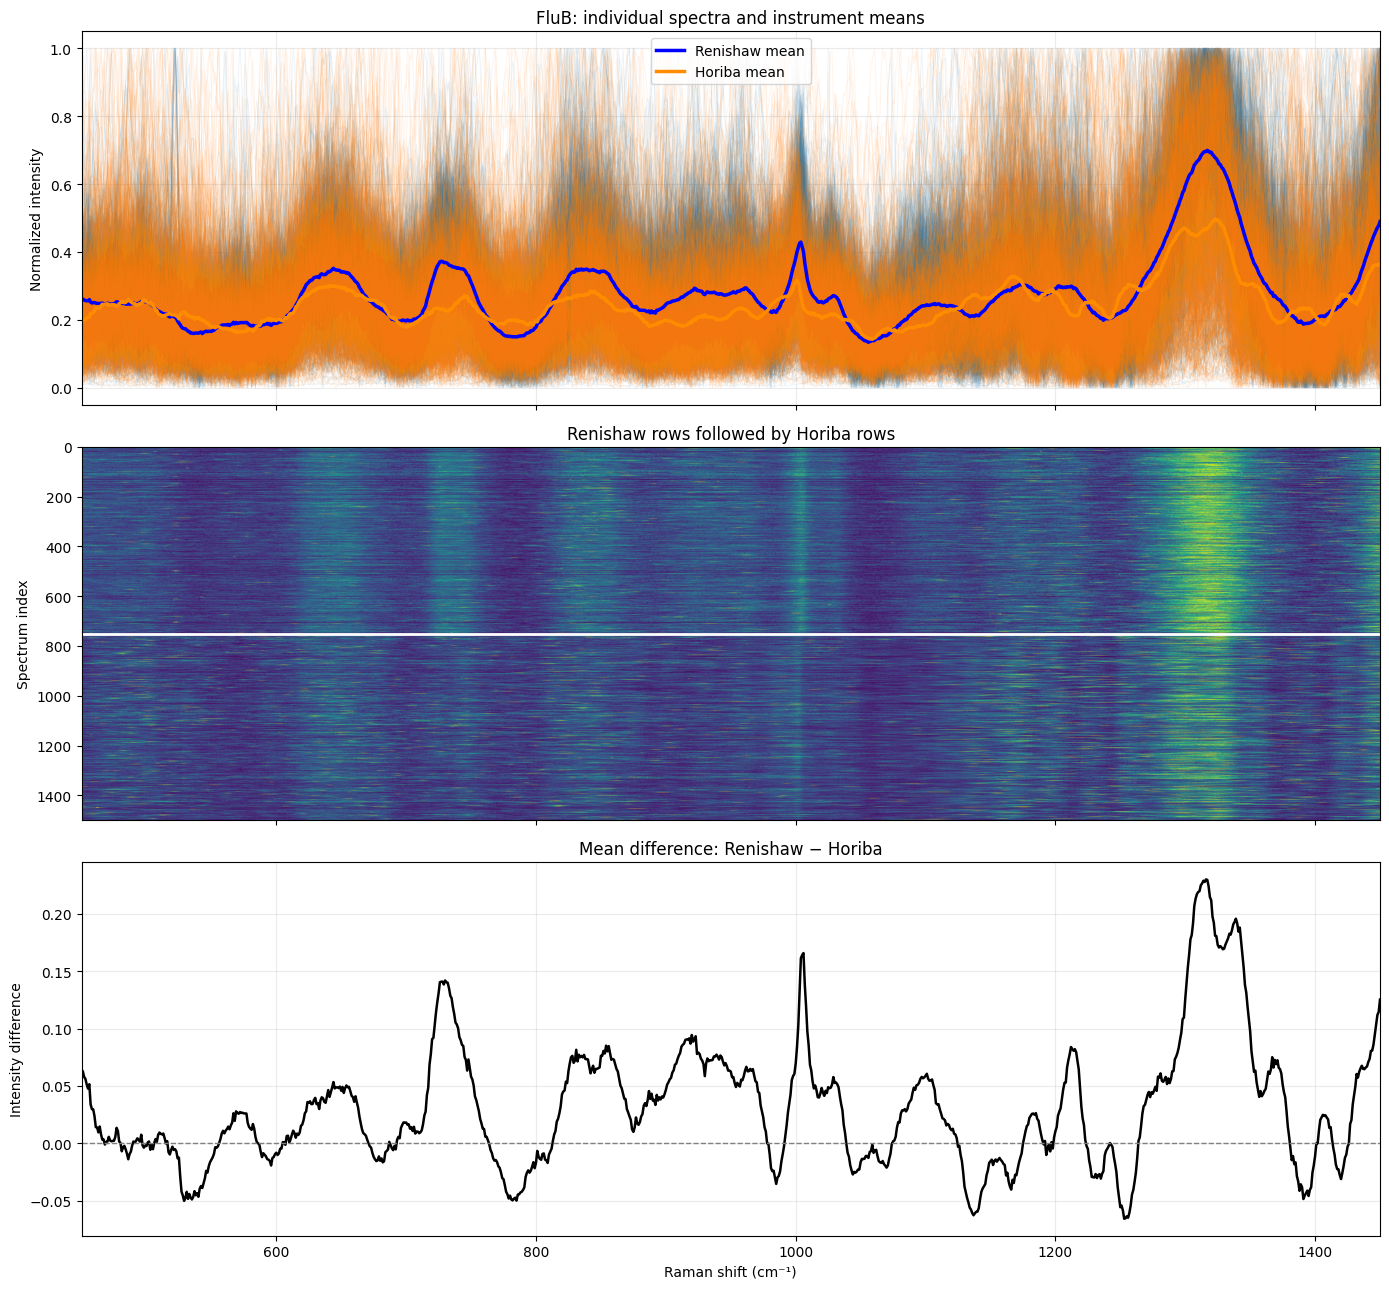

In [81]:
comparison_data = plot_spectra_comparison(
    renishaw_train,
    horiba_test,
    label_col="Virus",
    target_class="FluB",
)

# distinguish instrument

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader


# -----------------------
# Parameters
# -----------------------
instrument_lr = 8e-4
instrument_batch_size = 128
instrument_n_epochs = 100
instrument_random_state = 42

label_col = "Virus"
target_class = "dl-ala"

instrument_names = ["Renishaw", "Horiba"]
instrument_to_idx = {"Renishaw": 0, "Horiba": 1}
idx_to_instrument = {0: "Renishaw", 1: "Horiba"}


# -----------------------
# Feature preparation
# -----------------------
def get_numeric_feature_cols(df, label_col="Virus"):
    cols = []
    for col in df.columns:
        if col == label_col:
            continue
        try:
            float(col)
            cols.append(col)
        except ValueError:
            pass

    return sorted(cols, key=lambda x: float(x))


renishaw_cols = get_numeric_feature_cols(renishaw_train, label_col)
horiba_cols = get_numeric_feature_cols(horiba_test, label_col)

feature_cols = sorted(
    list(set(renishaw_cols).intersection(set(horiba_cols))),
    key=lambda x: float(x),
)

wavenumbers = np.array(feature_cols, dtype=float)

renishaw_target = (
    renishaw_train
    .loc[renishaw_train[label_col] == target_class, feature_cols]
    .astype(np.float32)
    .to_numpy()
)

horiba_target = (
    horiba_test
    .loc[horiba_test[label_col] == target_class, feature_cols]
    .astype(np.float32)
    .to_numpy()
)

X = np.vstack([renishaw_target, horiba_target]).astype(np.float32)
y = np.array(
    [instrument_to_idx["Renishaw"]] * len(renishaw_target)
    + [instrument_to_idx["Horiba"]] * len(horiba_target)
)

print("Renishaw target class:", renishaw_target.shape)
print("Horiba target class:", horiba_target.shape)
print("Combined:", X.shape)


# -----------------------
# Train/validation split
# -----------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=instrument_random_state,
    stratify=y,
)


# -----------------------
# Model
# -----------------------
class InstrumentCNN1d(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 32, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(32, 64, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=2),

            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)

        x = self.features(x)
        return self.classifier(x)


device = "cuda" if torch.cuda.is_available() else "cpu"

instrument_model = InstrumentCNN1d(n_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(instrument_model.parameters(), lr=instrument_lr)

train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.long),
    ),
    batch_size=instrument_batch_size,
    shuffle=True,
)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(y_val, dtype=torch.long).to(device)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}


# -----------------------
# Training
# -----------------------
for epoch in range(instrument_n_epochs):
    instrument_model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = instrument_model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = total_loss / total
    train_acc = correct / total

    instrument_model.eval()
    with torch.no_grad():
        val_logits = instrument_model(X_val_tensor)
        val_loss = criterion(val_logits, y_val_tensor).item()
        val_preds = val_logits.argmax(dim=1)
        val_acc = (val_preds == y_val_tensor).float().mean().item()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:03d}/{instrument_n_epochs} | "
            f"train acc: {train_acc:.4f} | val acc: {val_acc:.4f}"
        )


# -----------------------
# Classification results
# -----------------------
instrument_model.eval()
with torch.no_grad():
    val_logits = instrument_model(X_val_tensor)
    y_pred = val_logits.argmax(dim=1).cpu().numpy()

print(
    classification_report(
        y_val,
        y_pred,
        target_names=instrument_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Instrument Classifier Confusion Matrix")
plt.xticks([0, 1], instrument_names)
plt.yticks([0, 1], instrument_names)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar()
plt.tight_layout()
plt.show()


# -----------------------
# Training metrics
# -----------------------
epochs = np.arange(1, instrument_n_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"], label="Validation")
axes[0].set_title("Instrument Classifier Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"], label="Validation")
axes[1].set_title("Instrument Classifier Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# -----------------------
# Gradient feature importance
# -----------------------
def compute_instrument_feature_importance(model, X_input, target_class_idx=None, device="cuda"):
    model.eval()

    X_tensor = torch.tensor(X_input, dtype=torch.float32, device=device)
    X_tensor.requires_grad_(True)

    logits = model(X_tensor)

    if target_class_idx is None:
        target_scores = logits.max(dim=1).values
    else:
        target_scores = logits[:, target_class_idx]

    model.zero_grad()
    target_scores.sum().backward()

    importance = X_tensor.grad.abs().detach().cpu().numpy()
    importance = importance.mean(axis=0)

    importance = importance / (importance.max() + 1e-12)

    return importance


importance_any = compute_instrument_feature_importance(
    instrument_model,
    X_val,
    target_class_idx=None,
    device=device,
)

importance_renishaw = compute_instrument_feature_importance(
    instrument_model,
    X_val,
    target_class_idx=instrument_to_idx["Renishaw"],
    device=device,
)

importance_horiba = compute_instrument_feature_importance(
    instrument_model,
    X_val,
    target_class_idx=instrument_to_idx["Horiba"],
    device=device,
)


# -----------------------
# Plot importance maps
# -----------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(wavenumbers, importance_any, color="black")
axes[0].set_title("Feature Importance for Instrument Separation")
axes[0].set_ylabel("Importance")
axes[0].grid(alpha=0.3)

axes[1].plot(wavenumbers, importance_renishaw, color="tab:blue")
axes[1].set_title("Feature Importance Toward Renishaw")
axes[1].set_ylabel("Importance")
axes[1].grid(alpha=0.3)

axes[2].plot(wavenumbers, importance_horiba, color="tab:orange")
axes[2].set_title("Feature Importance Toward Horiba")
axes[2].set_xlabel("Wavenumber")
axes[2].set_ylabel("Importance")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
renishaw_avg = renishaw_target.mean(axis=0)
horiba_avg = horiba_target.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(14, 5))

# Average spectra
ax1.plot(
    wavenumbers,
    renishaw_avg,
    color="tab:blue",
    linewidth=2.5,
    label="Renishaw target-class mean",
)

ax1.plot(
    wavenumbers,
    horiba_avg,
    color="tab:orange",
    linewidth=2.5,
    label="Horiba target-class mean",
)

ax1.set_xlabel("Wavenumber")
ax1.set_ylabel("Average intensity")
ax1.grid(alpha=0.3)

# Feature importance on second axis
ax2 = ax1.twinx()

ax2.plot(
    wavenumbers,
    importance_smooth,
    color="black",
    linewidth=1.8,
    alpha=0.85,
    label="Instrument importance",
)

ax2.fill_between(
    wavenumbers,
    importance_smooth,
    color="black",
    alpha=0.12,
)

ax2.set_ylabel("Feature importance")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right",
)

plt.title("Instrument Feature Importance over Average Target-Class Spectra")
plt.tight_layout()
plt.show()

In [ ]:
def smooth_importance(x, window=21):
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="same")


importance_smooth = smooth_importance(importance_any, window=21)

importance_threshold = np.quantile(importance_smooth, 0.6)

unchanged_mask = importance_smooth < importance_threshold
transform_mask = importance_smooth >= importance_threshold

In [ ]:
from scipy.ndimage import gaussian_filter1d

renishaw_avg = renishaw_target.mean(axis=0)
horiba_avg = horiba_target.mean(axis=0)

renishaw_std = renishaw_target.std(axis=0)
horiba_std = horiba_target.std(axis=0)

mean_diff = np.abs(renishaw_avg - horiba_avg)

pooled_std = np.sqrt((renishaw_std ** 2 + horiba_std ** 2) / 2)
effect_size = mean_diff / (pooled_std + 1e-8)

importance_smooth = gaussian_filter1d(importance_any, sigma=4)
effect_smooth = gaussian_filter1d(effect_size, sigma=4)

importance_smooth = importance_smooth / (importance_smooth.max() + 1e-12)
effect_smooth = effect_smooth / (effect_smooth.max() + 1e-12)

domain_shift_score = importance_smooth * effect_smooth
domain_shift_score = gaussian_filter1d(domain_shift_score, sigma=3)
domain_shift_score = domain_shift_score / (domain_shift_score.max() + 1e-12)

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(wavenumbers, renishaw_avg, color="tab:blue", linewidth=2.5, label="Renishaw target-class mean")
ax1.plot(wavenumbers, horiba_avg, color="tab:orange", linewidth=2.5, label="Horiba target-class mean")
ax1.set_xlabel("Wavenumber")
ax1.set_ylabel("Average intensity")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    wavenumbers,
    domain_shift_score,
    color="black",
    linewidth=2,
    label="Domain-shift score",
)
ax2.fill_between(
    wavenumbers,
    domain_shift_score,
    color="black",
    alpha=0.15,
)
ax2.set_ylabel("Domain-shift score")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Selective Instrument Domain-Shift Score")
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------
# Build transformation mask
# -----------------------
threshold = np.quantile(domain_shift_score, 0.65)
transform_mask = domain_shift_score >= threshold

# Smooth mask so transformation changes gradually across wavenumbers
from scipy.ndimage import gaussian_filter1d

soft_mask = gaussian_filter1d(transform_mask.astype(float), sigma=4)
soft_mask = soft_mask / (soft_mask.max() + 1e-12)

plt.figure(figsize=(14, 3))
plt.plot(wavenumbers, domain_shift_score, color="black", label="Domain-shift score")
plt.plot(wavenumbers, soft_mask, color="red", label="Soft transform mask")
plt.xlabel("Wavenumber")
plt.ylabel("Score / mask")
plt.title("Transformation Mask")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -----------------------
# Transform Horiba toward Renishaw
# -----------------------
correction_strength = 1.0  # try 0.25, 0.5, 0.75, 1.0

renishaw_avg = renishaw_target.mean(axis=0)
horiba_avg = horiba_target.mean(axis=0)

mean_shift = renishaw_avg - horiba_avg

horiba_target_transformed = (
    horiba_target
    + correction_strength * soft_mask * mean_shift
)

In [ ]:
horiba_avg_transformed = horiba_target_transformed.mean(axis=0)

plt.figure(figsize=(14, 5))

plt.plot(wavenumbers, renishaw_avg, color="tab:blue", linewidth=2.5, label="Renishaw avg")
plt.plot(wavenumbers, horiba_avg, color="tab:orange", linewidth=2.0, label="Horiba avg original")
plt.plot(
    wavenumbers,
    horiba_avg_transformed,
    color="tab:green",
    linewidth=2.0,
    label="Horiba avg transformed",
)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity")
plt.title("Horiba Target class Transformation Toward Renishaw")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
X_eval_original = np.vstack([renishaw_target, horiba_target]).astype(np.float32)
y_eval = np.array(
    [instrument_to_idx["Renishaw"]] * len(renishaw_target)
    + [instrument_to_idx["Horiba"]] * len(horiba_target)
)

X_eval_transformed = np.vstack([renishaw_target, horiba_target_transformed]).astype(np.float32)

with torch.no_grad():
    original_logits = instrument_model(torch.tensor(X_eval_original, dtype=torch.float32).to(device))
    transformed_logits = instrument_model(torch.tensor(X_eval_transformed, dtype=torch.float32).to(device))

original_preds = original_logits.argmax(dim=1).cpu().numpy()
transformed_preds = transformed_logits.argmax(dim=1).cpu().numpy()

print("Original instrument classification:")
print(classification_report(y_eval, original_preds, target_names=instrument_names, zero_division=0))

print("After transformation:")
print(classification_report(y_eval, transformed_preds, target_names=instrument_names, zero_division=0))

In [ ]:
horiba_target_labels = np.array([class_to_idx["dl-ala"]] * len(horiba_target_transformed))

cnn1d.plot_classification_results(
    horiba_target_transformed,
    horiba_target_labels,
    idx_to_class=idx_to_class,
    normalize=False,
)

In [ ]:
# -----------------------
# Replace Horiba target class spectra with transformed spectra
# -----------------------
horiba_everything_transformed = horiba_everything.copy()

target_mask = horiba_everything_transformed[label_col] == "dl-ala"
n_target_rows = target_mask.sum()

print("Target-class rows in horiba_everything:", n_target_rows)
print("Transformed target spectra:", horiba_target_transformed.shape[0])

if n_target_rows != horiba_target_transformed.shape[0]:
    raise ValueError(
        f"Mismatch: horiba_everything has {n_target_rows} target-class rows, "
        f"but horiba_target_transformed has {horiba_target_transformed.shape[0]} rows."
    )

horiba_everything_transformed.loc[target_mask, feature_cols] = horiba_target_transformed

print("Replacement complete.")

# Transformer Model Training

Train and evaluate a Raman Transformer classifier on the cleaned spectral datasets.


In [99]:
lr=8e-4 # change 1e-3, 4, 5
batch_size=512
dl_n_epochs=50 # change to ~200


In [281]:
class RamanTransformer(nn.Module):
    """Transformer encoder for one-dimensional Raman spectra.

    The spectrum is divided into short contiguous patches. Each patch becomes a
    token, and self-attention learns relationships between peaks anywhere in the
    measured wavenumber range. The public ``features`` method is retained because
    the domain-adaptation section uses classifier embeddings in its feature loss.
    """

    def __init__(
        self,
        n_classes,
        patch_size=16,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=128,
        dropout=0.1,
        max_patches=128,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError("d_model must be divisible by nhead")

        self.patch_size = patch_size
        self.max_patches = max_patches

        # A strided convolution is a learned, non-overlapping spectral patch embedder.
        self.patch_embed = nn.Conv1d(
            1,
            d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embedding = nn.Parameter(
            torch.zeros(1, max_patches + 1, d_model)
        )
        self.embedding_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, n_classes),
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)

    def _tokenize(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(1)
        elif x.ndim != 3 or x.shape[1] != 1:
            raise ValueError(
                "Expected shape (batch, length) or (batch, 1, length), "
                f"got {tuple(x.shape)}"
            )

        if x.shape[0] == 0:
            raise ValueError("Input tensor has 0 rows.")

        # Preserve the end of a spectrum when its length is not a patch multiple.
        pad_right = (-x.shape[-1]) % self.patch_size
        if pad_right:
            x = F.pad(x, (0, pad_right), mode="replicate")

        tokens = self.patch_embed(x).transpose(1, 2)
        if tokens.shape[1] > self.max_patches:
            raise ValueError(
                f"Spectrum creates {tokens.shape[1]} patches, but max_patches="
                f"{self.max_patches}. Increase max_patches or patch_size."
            )
        return tokens

    def features(self, x):
        tokens = self._tokenize(x)
        cls = self.cls_token.expand(tokens.shape[0], -1, -1)
        tokens = torch.cat((cls, tokens), dim=1)
        tokens = tokens + self.pos_embedding[:, :tokens.shape[1]]
        encoded = self.encoder(self.embedding_dropout(tokens))
        return encoded[:, 0]

    def forward(self, x):
        return self.classifier(self.features(x))


model = RamanTransformer(n_classes=2)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total number of trainable parameters: {count_parameters(model):,}")


Total number of trainable parameters: 1,359,106


/tmp/ipykernel_827/1625554061.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


In [282]:
class Classifier:
    """Portable training wrapper retained for the domain-adaptation section."""

    def __init__(self, n_class, device=None):
        self.device = torch.device(
            device or ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.net = RamanTransformer(n_class).to(self.device)
        self.train_loss = []
        self.val_loss = []

    def fit(self, train_set, train_labels, test_set, test_labels, modelname="raman_transformer"):
        train_x = torch.as_tensor(train_set, dtype=torch.float32)
        train_y = torch.as_tensor(train_labels, dtype=torch.long)
        val_x = torch.as_tensor(test_set, dtype=torch.float32, device=self.device)
        val_y = torch.as_tensor(test_labels, dtype=torch.long, device=self.device)

        train_loader = DataLoader(
            TensorDataset(train_x, train_y),
            batch_size=batch_size,
            shuffle=True,
        )
        optimizer = torch.optim.AdamW(
            self.net.parameters(), lr=lr, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[60, 90], gamma=0.1
        )
        loss_func = nn.CrossEntropyLoss()

        for epoch in range(dl_n_epochs):
            self.net.train()
            running_loss = 0.0
            train_correct = 0
            train_total = 0

            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(self.device)
                batch_y = batch_y.to(self.device)
                optimizer.zero_grad(set_to_none=True)
                logits = self.net(batch_x)
                loss = loss_func(logits, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.net.parameters(), 1.0)
                optimizer.step()

                running_loss += loss.item() * batch_x.shape[0]
                train_correct += (logits.argmax(1) == batch_y).sum().item()
                train_total += batch_y.numel()

            scheduler.step()
            train_loss = running_loss / train_total
            train_acc = train_correct / train_total

            self.net.eval()
            with torch.no_grad():
                val_logits = self.net(val_x)
                val_loss = loss_func(val_logits, val_y).item()
                val_acc = (val_logits.argmax(1) == val_y).float().mean().item()

            self.train_loss.append(train_loss)
            self.val_loss.append(val_loss)
            print(
                f"Epoch {epoch + 1:03d}/{dl_n_epochs} | "
                f"train loss {train_loss:.4f} | train acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} | val acc {val_acc:.4f}"
            )

        torch.save(self.net.state_dict(), f"{modelname}.pt")
        return self

    def predict(self, test_set):
        self.net.eval()
        test_x = torch.as_tensor(test_set, dtype=torch.float32)
        loader = DataLoader(TensorDataset(test_x), batch_size=batch_size, shuffle=False)
        predictions = []
        with torch.no_grad():
            for (batch_x,) in loader:
                logits = self.net(batch_x.to(self.device))
                predictions.append(logits.argmax(1).cpu().numpy())
        return np.concatenate(predictions)

In [283]:
def compute_transformer_feature_importance_per_class(
    model, X, y, wavenumbers, num_classes, max_samples=100, random_state=42
):
    """Mean absolute input-gradient attribution for each Raman class."""
    if X.ndim != 2:
        raise ValueError(f"Expected a 2-D spectral matrix, got shape {X.shape}.")
    if X.shape[1] != len(wavenumbers):
        raise ValueError("The wavenumber axis does not match the spectral width.")

    network = model.net if hasattr(model, "net") else model
    device = next(network.parameters()).device
    network.eval()
    rng = np.random.default_rng(random_state)
    importance = np.zeros((num_classes, X.shape[1]), dtype=np.float32)

    for class_index in range(num_classes):
        indices = np.flatnonzero(y == class_index)
        if len(indices) == 0:
            print(f"Skipping class {class_index}: no samples found.")
            continue
        if len(indices) > max_samples:
            indices = rng.choice(indices, size=max_samples, replace=False)

        inputs = torch.as_tensor(X[indices], dtype=torch.float32, device=device)
        inputs.requires_grad_(True)
        logits = network(inputs)
        selected_score = logits[:, class_index].sum()
        gradients = torch.autograd.grad(selected_score, inputs)[0]
        class_importance = gradients.abs().mean(dim=0).detach().cpu().numpy()
        scale = class_importance.max()
        if scale > 0:
            class_importance /= scale
        importance[class_index] = class_importance

    return importance


# Compatibility alias for any older analysis cells.
compute_cnn_feature_importance_per_class = compute_transformer_feature_importance_per_class

In [284]:
def visualize(frame, label_col="Virus", random_state=42):
    """Plot PCA and t-SNE projections for any prepared spectral dataframe."""
    spectral_cols = get_spectral_columns(frame)
    if label_col not in frame.columns:
        raise ValueError(f"Missing label column: {label_col}")
    if len(frame) < 3:
        raise ValueError("At least three spectra are required for visualization.")

    spectra = frame[spectral_cols].to_numpy(dtype=np.float32)
    labels = frame[label_col].astype(str).reset_index(drop=True)

    pca_result = PCA(n_components=2).fit_transform(spectra)
    perplexity = min(30, max(2, (len(frame) - 1) // 3))
    tsne_result = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(spectra)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for label in sorted(labels.unique()):
        mask = labels.eq(label).to_numpy()
        axes[0].scatter(pca_result[mask, 0], pca_result[mask, 1], label=label, alpha=0.45, s=16)
        axes[1].scatter(tsne_result[mask, 0], tsne_result[mask, 1], label=label, alpha=0.45, s=16)

    axes[0].set(title="PCA of Raman spectra", xlabel="PC1", ylabel="PC2")
    axes[1].set(title="t-SNE of Raman spectra", xlabel="Component 1", ylabel="Component 2")
    for axis in axes:
        axis.grid(alpha=0.25)
    axes[1].legend(title=label_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [285]:
def build_balanced_comparison(predicted_frame, reference_frame, classes=("FluB", "IBV"), n=375):
    """Build a balanced comparison without relying on hidden global variables."""
    selected = []
    for origin, frame in (("predicted", predicted_frame), ("reference", reference_frame)):
        for label in classes:
            group = frame.loc[frame["Virus"] == label]
            if len(group) < n:
                raise ValueError(f"{origin} has only {len(group)} rows for {label}; requested {n}.")
            part = group.sample(n=n, random_state=42).copy()
            part["DataOrigin"] = origin
            selected.append(part)
    return pd.concat(selected, ignore_index=True)


# Example (only run when predicted_df has been created):
# final_dataset = build_balanced_comparison(predicted_df, sampled_renishaw)
# print(final_dataset.groupby(["DataOrigin", "Virus"]).size())

In [286]:
#renishaw_train = norm_renishaw.iloc[:, :-2]
#horiba_test = norm_df.iloc[:, :-2]

renishaw_train = renishaw_everything.iloc[:, :-2]
horiba_test = horiba_everything.iloc[:, :-2]


In [287]:
horiba_test


,450,451,452,453,454,455,456,457,458,459,...,1241,1242,1243,1244,1245,1246,1247,1248,1249,Virus
0,0.043083,0.041606,0.045071,0.041589,0.047674,0.048541,0.041094,0.036792,0.029718,0.035937,...,0.022494,0.032141,0.016700,0.019122,0.009884,0.017744,0.016294,0.013100,0.014716,adenine
1,0.034018,0.029939,0.038426,0.037149,0.036553,0.034334,0.030238,0.037424,0.034567,0.023828,...,0.034951,0.033970,0.029036,0.025265,0.017042,0.021623,0.020551,0.010907,0.005525,adenine
2,0.037365,0.037414,0.035671,0.036161,0.029404,0.029358,0.039614,0.032079,0.029076,0.030315,...,0.030143,0.018698,0.021143,0.019889,0.011995,0.015700,0.010580,0.013936,0.016151,adenine
3,0.041881,0.040419,0.038913,0.042708,0.040538,0.037994,0.040990,0.039308,0.037925,0.033701,...,0.017117,0.007620,0.015976,0.008975,0.014406,0.006229,0.010229,0.010957,0.010196,adenine
4,0.042533,0.033678,0.031971,0.042148,0.038365,0.039792,0.028405,0.031023,0.039149,0.037384,...,0.032823,0.032591,0.026484,0.036598,0.041640,0.032822,0.026221,0.019249,0.013414,adenine
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,0.120955,0.115952,0.098673,0.141202,0.086399,0.086519,0.071147,0.066950,0.114683,0.098462,...,0.029123,0.071841,0.075413,0.061235,0.152394,0.082950,0.041585,0.070041,0.046763,Lipid
4496,0.243701,0.254938,0.323203,0.379185,0.390608,0.330583,0.292423,0.203009,0.139460,0.143947,...,0.229013,0.194490,0.180797,0.223395,0.134469,0.178879,0.113422,0.161098,0.130063,Lipid
4497,0.233404,0.271014,0.361179,0.317449,0.301888,0.274750,0.244785,0.263440,0.181727,0.277039,...,0.070777,0.257277,0.227758,0.348603,0.260801,0.393077,0.593402,0.287712,0.441355,Lipid
4498,0.209253,0.211445,0.271954,0.380374,0.178492,0.250696,0.201641,0.176182,0.322835,0.416785,...,0.227254,0.167831,0.357787,0.205388,0.162294,0.280089,0.243497,0.148284,0.128885,Lipid


In [288]:
print(horiba_test['Virus'].value_counts())
print(renishaw_train['Virus'].value_counts())


Virus
adenine    750
dl-ala     750
dl-phe     750
dl-tyr     750
glu        750
RNA        375
Lipid      375
Name: count, dtype: int64
Virus
adenine    750
dl-ala     750
dl-phe     750
dl-tyr     750
glu        750
RNA        375
Lipid      375
Name: count, dtype: int64


In [289]:
CLASSES = ["adenine", "dl-ala", "dl-phe", "dl-tyr", "glu", "RNA", "Lipid"]
CLASSES2IDX = {label: index for index, label in enumerate(CLASSES)}
IDX2CLASSES = {index: label for label, index in CLASSES2IDX.items()}

feature_cols = sorted(
    set(get_spectral_columns(renishaw_train)).intersection(get_spectral_columns(horiba_test)),
    key=float,
)
train_val_set = renishaw_train.loc[renishaw_train["Virus"].isin(CLASSES)].copy()
train_val_set = (
    train_val_set.groupby("Virus", group_keys=False)
    .apply(sample_up_to_n, n=10000)
    .reset_index(drop=True)
)

train_val_labels = train_val_set["Virus"].map(CLASSES2IDX).to_numpy(dtype=np.int64)
train_val_features = train_val_set[feature_cols].to_numpy(dtype=np.float32)
feature_list = np.asarray(feature_cols, dtype=float)

train_set, validate_set, train_labels, validate_labels = train_test_split(
    train_val_features,
    train_val_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_val_labels,
)

cnn1d = Classifier(len(CLASSES))  # Kept as an alias for downstream analysis cells.
cnn1d.fit(train_set, train_labels, validate_set, validate_labels, modelname="raman_transformer")

/tmp/ipykernel_827/2032466228.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(sample_up_to_n, n=10000)
/tmp/ipykernel_827/1625554061.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


Epoch 001/50 | train loss 2.0505 | train acc 0.1978 | val loss 1.7312 | val acc 0.2111
Epoch 002/50 | train loss 1.6426 | train acc 0.3378 | val loss 1.5477 | val acc 0.3856
Epoch 003/50 | train loss 1.5435 | train acc 0.3889 | val loss 1.3760 | val acc 0.5267
Epoch 004/50 | train loss 1.4149 | train acc 0.4569 | val loss 1.3375 | val acc 0.4567
Epoch 005/50 | train loss 1.3186 | train acc 0.5250 | val loss 1.1522 | val acc 0.6067
Epoch 006/50 | train loss 1.1827 | train acc 0.5794 | val loss 1.0258 | val acc 0.6411
Epoch 007/50 | train loss 1.0125 | train acc 0.6389 | val loss 0.7787 | val acc 0.7289
Epoch 008/50 | train loss 0.8106 | train acc 0.7281 | val loss 0.6422 | val acc 0.7744
Epoch 009/50 | train loss 0.6889 | train acc 0.7622 | val loss 0.5406 | val acc 0.8067
Epoch 010/50 | train loss 0.5744 | train acc 0.7953 | val loss 0.5022 | val acc 0.8267
Epoch 011/50 | train loss 0.5376 | train acc 0.8092 | val loss 0.4838 | val acc 0.8133
Epoch 012/50 | train loss 0.4589 | train ac

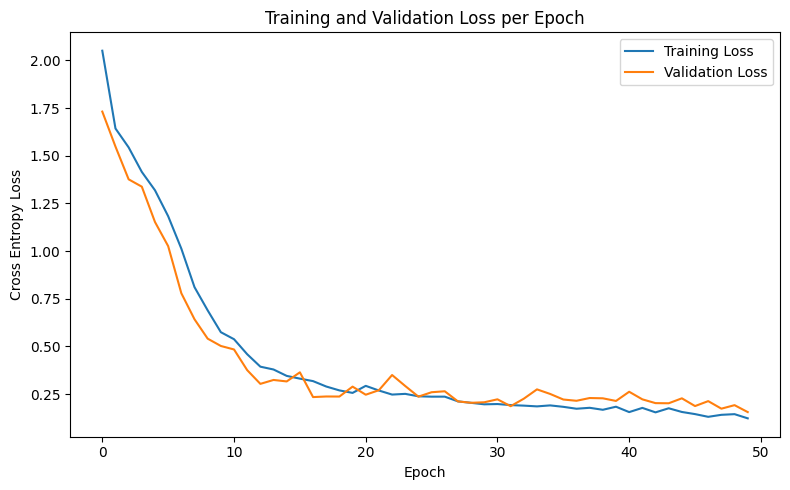

In [290]:
plt.figure(figsize=(8, 5))
plt.plot(cnn1d.train_loss, label='Training Loss')
plt.plot(cnn1d.val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.tight_layout()
plt.show()


In [291]:
renishaw_eval = renishaw_train.loc[renishaw_train["Virus"].isin(CLASSES)].copy()
horiba_eval = horiba_test.loc[horiba_test["Virus"].isin(CLASSES)].copy()

test_labels = renishaw_eval["Virus"].map(CLASSES2IDX).to_numpy(dtype=np.int64)
test_labels_2 = horiba_eval["Virus"].map(CLASSES2IDX).to_numpy(dtype=np.int64)
test_labels_3 = validate_labels
test_features = renishaw_eval[feature_cols].to_numpy(dtype=np.float32)
test_features_2 = horiba_eval[feature_cols].to_numpy(dtype=np.float32)
test_features_3 = validate_set

In [292]:
predicted_labels = cnn1d.predict(test_features).flatten()
predicted_labels_2 = cnn1d.predict(test_features_2).flatten()
predicted_labels_3 = cnn1d.predict(test_features_3).flatten().flatten().flatten()

In [293]:
test_accuracy = accuracy_score(test_labels, predicted_labels)
print(f"Test Accuracy on Renishaw Data: {test_accuracy:.2%}")
test_precision = precision_score(test_labels, predicted_labels, average='weighted')
print(f"Test Precision on Renishaw Data: {test_precision:.2%}")
test_recall = recall_score(test_labels, predicted_labels, average='weighted')
print(f"Test Recall on Renishaw Data: {test_recall:.2%}")

test_accuracy_2 = accuracy_score(test_labels_2, predicted_labels_2)
print(f"Test Accuracy on Predicted Data: {test_accuracy_2:.2%}")
test_precision_2 = precision_score(test_labels_2, predicted_labels_2, average='weighted')
print(f"Test Precision on Predicted Data: {test_precision_2:.2%}")
test_recall_2 = recall_score(test_labels_2, predicted_labels_2, average='weighted')
print(f"Test Recall on Predicted Data: {test_recall_2:.2%}")

test_accuracy_3 = accuracy_score(test_labels_3, predicted_labels_3)
print(f"Test Accuracy on Validation Data: {test_accuracy_3:.2%}")
test_precision_3 = precision_score(test_labels_3, predicted_labels_3, average='weighted')
print(f"Test Precision on Validation Data: {test_precision_3:.2%}")
test_recall_3 = recall_score(test_labels_3, predicted_labels_3, average='weighted')
print(f"Test Recall on Validation Data: {test_recall_3:.2%}")


Test Accuracy on Renishaw Data: 96.09%
Test Precision on Renishaw Data: 96.24%
Test Recall on Renishaw Data: 96.09%
Test Accuracy on Predicted Data: 52.84%
Test Precision on Predicted Data: 57.44%
Test Recall on Predicted Data: 52.84%
Test Accuracy on Validation Data: 94.56%
Test Precision on Validation Data: 94.73%
Test Recall on Validation Data: 94.56%


In [294]:
a = pd.DataFrame(predicted_labels_2)
a.value_counts()


,count
0,
5,1067
6,800
0,761
1,621
4,603
2,466
3,182


In [295]:
horiba_test['Virus'].value_counts()


,count
Virus,
adenine,750
dl-ala,750
dl-phe,750
dl-tyr,750
glu,750
RNA,375
Lipid,375


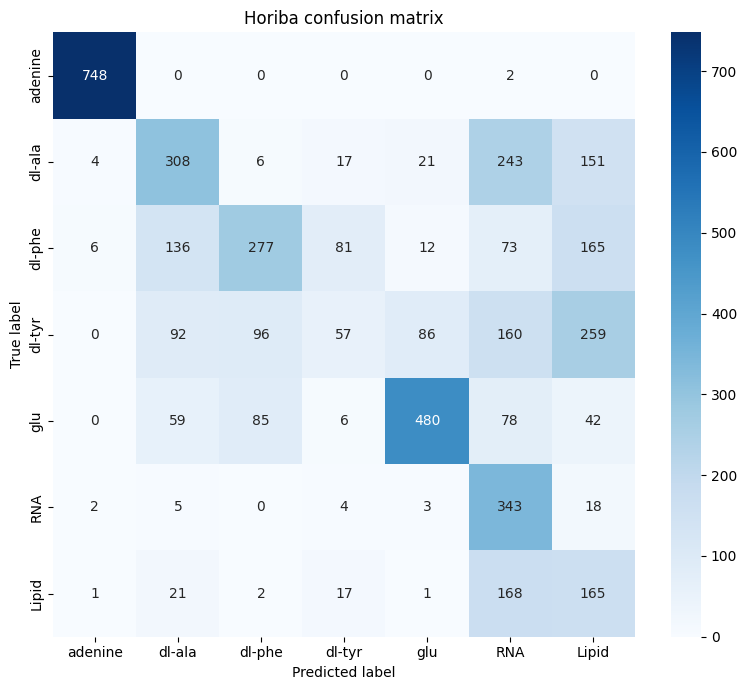

In [296]:
cm = confusion_matrix(test_labels_2, predicted_labels_2, labels=range(len(CLASSES)))
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Horiba confusion matrix")
plt.tight_layout()
plt.show()

In [ ]:
cm = confusion_matrix(test_labels_3, predicted_labels_3, labels=range(len(CLASSES)))
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Validation confusion matrix")
plt.tight_layout()
plt.show()

In [ ]:
true = np.asarray(test_labels_2)
pred = np.asarray(predicted_labels_2).reshape(-1)
spectra = test_features_2

if not (len(true) == len(pred) == len(spectra)):
    raise ValueError("Labels, predictions, and spectra must have the same number of rows.")

mis_idx = np.flatnonzero(true != pred)
print("Number misclassified:", len(mis_idx))

In [ ]:
mis_idx


## Removed: classifier-driven row deletion

The previous cells deleted rows from independent Renishaw and Horiba datasets using
positions from a filtered Horiba prediction array. Those positions did not identify
the same physical samples and would bias subsequent evaluation. Misclassifications
are now analyzed without mutating any source dataset.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
# Intentionally left empty; see the data-leakage note above.

In [ ]:
misclassified_by_class = {}

for idx in mis_idx:
    t = true[idx]
    if t not in misclassified_by_class:
        misclassified_by_class[t] = []
    misclassified_by_class[t].append(idx)


In [ ]:
classes = np.unique(true)
wavenumbers = feature_list if len(feature_list) == spectra.shape[1] else np.arange(spectra.shape[1])

for class_index in classes:
    candidates = misclassified_by_class.get(class_index, [])
    if not candidates:
        print(f"No misclassifications for class {IDX2CLASSES.get(class_index, class_index)}")
        continue

    samples = random.sample(candidates, k=min(3, len(candidates)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), squeeze=False)
    for axis, sample_index in zip(axes.ravel(), samples):
        axis.plot(wavenumbers, spectra[sample_index], color="black")
        axis.set_title(
            f"True: {IDX2CLASSES.get(true[sample_index], true[sample_index])} | "
            f"Pred: {IDX2CLASSES.get(pred[sample_index], pred[sample_index])}"
        )
        axis.set_xlabel("Wavenumber")
    plt.tight_layout()
    plt.show()

In [ ]:
correct_idx = np.flatnonzero(true == pred)
print("Number correctly predicted:", len(correct_idx))

correct_by_class = {}
for sample_index in correct_idx:
    correct_by_class.setdefault(true[sample_index], []).append(sample_index)

wavenumbers = feature_list if len(feature_list) == spectra.shape[1] else np.arange(spectra.shape[1])
for class_index in np.unique(true):
    candidates = correct_by_class.get(class_index, [])
    if not candidates:
        print(f"No correct predictions for class {IDX2CLASSES.get(class_index, class_index)}")
        continue

    samples = random.sample(candidates, k=min(3, len(candidates)))
    fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 4), squeeze=False)
    for axis, sample_index in zip(axes.ravel(), samples):
        axis.plot(wavenumbers, spectra[sample_index], color="black")
        axis.set_title(f"Correct: {IDX2CLASSES.get(class_index, class_index)}")
        axis.set_xlabel("Wavenumber")
    plt.tight_layout()
    plt.show()

In [ ]:
# ---------- EXISTING CORRECT PREDICTION LOGIC ----------
correct_idx = np.where(true == pred)[0]
print("Number correctly predicted:", len(correct_idx))

correct_by_class = {}
incorrect_by_class = {}

for idx in range(len(true)):
    t = true[idx]

    # correct
    if true[idx] == pred[idx]:
        correct_by_class.setdefault(t, []).append(idx)
    else:
        incorrect_by_class.setdefault(t, []).append(idx)

wavenumbers = np.arange(spectra.shape[1])  # or use your actual wavenumber axis
unique_classes = np.unique(true)

# ---------- PLOT AVERAGE MISCLASSIFIED SPECTRUM ----------
for c in unique_classes:

    if c not in incorrect_by_class or len(incorrect_by_class[c]) == 0:
        print(f"No misclassified samples for class {c}")
        continue

    # compute average misclassified spectrum
    mis_idx = incorrect_by_class[c]
    avg_mis_spectrum = spectra[mis_idx].mean(axis=0)

    # plot
    plt.figure(figsize=(10,4))
    plt.plot(wavenumbers, avg_mis_spectrum, color='red', label="Avg Misclassified")
    plt.title(f"Average Misclassified Spectrum for Class {c}")
    plt.xlabel("Wavenumber")
    plt.ylabel("Intensity")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
for c in unique_classes:

    if c not in incorrect_by_class:
        continue

    avg_mis = spectra[incorrect_by_class[c]].mean(axis=0)
    avg_correct = spectra[correct_by_class[c]].mean(axis=0)

    plt.figure(figsize=(10,4))
    plt.plot(wavenumbers, avg_correct, color='green', label="Avg Correct")
    plt.plot(wavenumbers, avg_mis, color='red', linestyle='--', label="Avg Misclassified")
    plt.title(f"Correct vs Misclassified (Class {c})")
    plt.legend()
    plt.tight_layout()
    plt.show()


**Reasoning**:
The plotting lines currently produce a 2D array (1, 1001) for the y-axis, causing a ValueError. The fix involves flattening the arrays to a 1D shape (1001,) using `.values.flatten()` to match the x-axis dimensions for correct plotting.



In [ ]:
virus = "FluA"
strain = "CA"

original = df.loc[(df["Virus"] == virus) & (df["Strain"] == strain)].copy()
corrected = subbed_df.loc[
    (subbed_df["Virus"] == virus) & (subbed_df["Strain"] == strain)
].copy()

if original.empty or corrected.empty:
    raise ValueError(f"No spectra found for Virus={virus!r}, Strain={strain!r}.")

spec_cols = sorted(
    set(get_spectral_columns(original)).intersection(get_spectral_columns(corrected)),
    key=float,
)
sample_position = min(256, len(original) - 1, len(corrected) - 1)
x = np.asarray(spec_cols, dtype=float)
y_original = original.iloc[sample_position][spec_cols].to_numpy(dtype=float)
y_corrected = corrected.iloc[sample_position][spec_cols].to_numpy(dtype=float)

plt.figure(figsize=(10, 5))
plt.plot(x, y_original, label="Original spectrum", alpha=0.9)
plt.plot(x, y_corrected, label="Baseline-subtracted spectrum", alpha=0.9)
plt.title(f"Original vs. baseline-subtracted spectrum — {virus}, {strain}")
plt.xlabel("Raman shift (cm⁻¹)")
plt.ylabel("Intensity")
plt.legend()
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Confirm that the graph is now plotting correctly and summarize the changes made.


## Summary:

### Q&A
Yes, the graph is now plotting correctly without any errors. The plotting lines were modified to correctly extract the spectral data from single-row DataFrames into 1D NumPy arrays using `.values.flatten()`, which resolved the `ValueError` related to mismatched dimensions.

### Data Analysis Key Findings
*   The primary issue was a `ValueError` encountered during plotting, which occurred because 2D data (a 1xN DataFrame row) was being passed to `plt.plot` where a 1D array (N,) was expected for the y-axis.
*   The resolution involved modifying the plotting lines for both `sample1` and `sample2`.
*   Specifically, the code was changed from implicitly trying to plot a DataFrame row to explicitly converting it to a 1D NumPy array using `sample1[spec_cols_sorted].values.flatten()` and `sample2[spec_cols_sorted].values.flatten()`.
*   This ensured that the spectral data was correctly formatted as a 1D array, matching the required dimensions for plotting against the `x` (wavenumber) array.

### Insights or Next Steps
*   This method using `.values.flatten()` is an effective way to handle the conversion of single-row DataFrame slices into 1D arrays suitable for plotting functions expecting 1D input.
*   Ensure dimensional consistency between data arrays when plotting to prevent `ValueError` issues, especially when working with different data structures like DataFrames and NumPy arrays.


In [ ]:
renishaw_everything['Virus'].value_counts()

In [ ]:
df_plot = renishaw_everything.copy()

label_col = "Virus"
metadata_cols = ["Virus", "Subtype", "Strain"]

spectral_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

wavenumbers = np.array(spectral_cols, dtype=float)

class_means = (
    df_plot
    .groupby(label_col)[spectral_cols]
    .mean()
)

plt.figure(figsize=(13, 6))

for i, (virus, row) in enumerate(class_means.iterrows()):
    plt.plot(wavenumbers, row.values+i, label=f"{virus} (n={(df_plot[label_col] == virus).sum()})")

plt.xlabel("Wavenumber")
plt.ylabel("Mean normalized intensity")
plt.title("Mean Renishaw Spectrum by Virus Class")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_plot = horiba_everything.copy()

label_col = "Virus"
metadata_cols = ["Virus", "Subtype", "Strain"]

spectral_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(df_plot[c])
]

wavenumbers = np.array(spectral_cols, dtype=float)

class_means = (
    df_plot
    .groupby(label_col)[spectral_cols]
    .mean()
)

plt.figure(figsize=(13, 6))

for i, (virus, row) in enumerate(class_means.iterrows()):
    plt.plot(wavenumbers, row.values+i, label=f"{virus} (n={(df_plot[label_col] == virus).sum()})")

plt.xlabel("Wavenumber")
plt.ylabel("Mean normalized intensity")
plt.title("Mean Renishaw Spectrum by Virus Class")
plt.legend()
plt.tight_layout()
plt.show()